<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

## Ссылки на датасеты:

    dst-3.0_16_1_hh_database.csv
    https://drive.google.com/file/d/1H6VmFaVbwnt1sIA2VnClAwScnX4LxdhZ/view?usp=drive_link
   
    diabetes_data.zip
    https://drive.google.com/file/d/1eZzltlt1pHNLSSwr-vFZ37Q36WC8g6hN/view?usp=drive_link

    orders_and_products.zip
    https://drive.google.com/file/d/1HL8vPynq4cGV_LDBc6s9IcXtwMzHpeVj/view?usp=drive_link

    ratings_movies.zip
    https://drive.google.com/file/d/15amS1_6oChFTmm9i5ogeceWMIlPotC73/view?usp=drive_link

    citibike-tripdata.csv
    https://drive.google.com/file/d/1RNjuPrzdUEVevTJxFkAH46MohClWIBBU/view?usp=drive_link

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import math
from scipy.stats import linregress

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [160]:
# Чтение CSV файла
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')

In [161]:
# Читаем данные из Excel файла
#df = pd.read_excel('HH _updated.xlsx')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [162]:
# Выводим первые строки
print(df.head())

# Выводим информацию о структуре признака "Пол, возраст"
print(df['Пол, возраст'].head())

                                   Пол, возраст           ЗП  \
0    Мужчина ,  39 лет , родился 27 ноября 1979   29000 руб.   
1     Мужчина ,  60 лет , родился 20 марта 1959   40000 руб.   
2  Женщина ,  36 лет , родилась 12 августа 1982   20000 руб.   
3      Мужчина ,  38 лет , родился 25 июня 1980  100000 руб.   
4     Женщина ,  26 лет , родилась 3 марта 1993  140000 руб.   

                           Ищет работу на должность:  \
0                            Системный администратор   
1                               Технический писатель   
2                                           Оператор   
3  Веб-разработчик (HTML / CSS / JS / PHP / базы ...   
4                  Региональный менеджер по продажам   

                        Город, переезд, командировки  \
0  Советск (Калининградская область) , не готов к...   
1  Королев , не готов к переезду , готов к редким...   
2  Тверь , не готова к переезду , не готова к ком...   
3  Саратов , не готов к переезду , готов к редким...  

In [163]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 12

Названия столбцов:
1. Пол, возраст
2. ЗП
3. Ищет работу на должность:
4. Город, переезд, командировки
5. Занятость
6. График
7. Опыт работы
8. Последнее/нынешнее место работы
9. Последняя/нынешняя должность
10. Образование и ВУЗ
11. Обновление резюме
12. Авто

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы             

3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [164]:
print("Информация о числе непустых значений в столбцах и их типах в таблице:")
print(df.info())

Информация о числе непустых значений в столбцах и их типах в таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                   

4. Обратите внимание на информацию о числе непустых значений.

In [165]:
print("Анализ пропущенных значений:")

# Считаем пропуски по каждому столбцу
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Создаем DataFrame с информацией о пропусках
missing_info = pd.DataFrame({
    'Столбец': df.columns,
    'Непустых': df.notna().sum(),
    'Пустых': missing_data,
    '% Пустых': missing_percent.round(2)
})

print(missing_info)
print("\nСтолбцы с пропусками:")
columns_with_missing = missing_info[missing_info['Пустых'] > 0]['Столбец'].tolist()
for col in columns_with_missing:
    print(f"- {col}: {missing_info[missing_info['Столбец'] == col]['Пустых'].values[0]} пропусков")

Анализ пропущенных значений:
                                                         Столбец  Непустых  \
Пол, возраст                                        Пол, возраст     44744   
ЗП                                                            ЗП     44744   
Ищет работу на должность:              Ищет работу на должность:     44744   
Город, переезд, командировки        Город, переезд, командировки     44744   
Занятость                                              Занятость     44744   
График                                                    График     44744   
Опыт работы                                          Опыт работы     44576   
Последнее/нынешнее место работы  Последнее/нынешнее место работы     44743   
Последняя/нынешняя должность        Последняя/нынешняя должность     44742   
Образование и ВУЗ                              Образование и ВУЗ     44744   
Обновление резюме                              Обновление резюме     44744   
Авто                               

5. Выведите основную статистическую информацию о столбцах.


In [166]:
# Количество уникальных значений в столбце "Опыт работы"
unique_experience = df['Опыт работы'].nunique()
print(f"Количество уникальных значений в столбце 'Опыт работы': {unique_experience}")

# Самая распространенная искоммая должность
most_common_position = df['Ищет работу на должность:'].value_counts().head(1)
print(f"\nСамая распространенная искоммая должность:")
print(most_common_position)

# Дополнительная статистика по столбцам
print("\nОсновная статистическая информация:")
print(df.describe(include='all'))

Количество уникальных значений в столбце 'Опыт работы': 44413

Самая распространенная искоммая должность:
Ищет работу на должность:
Системный администратор    3099
Name: count, dtype: int64

Основная статистическая информация:
                                         Пол, возраст          ЗП  \
count                                           44744       44744   
unique                                          16003         690   
top     Мужчина ,  32 года , родился 17 сентября 1986  50000 руб.   
freq                                               18        4064   

       Ищет работу на должность:  \
count                      44744   
unique                     14929   
top      Системный администратор   
freq                        3099   

                             Город, переезд, командировки         Занятость  \
count                                               44744             44744   
unique                                              10063                38   
top     М

# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [167]:
# Создание признака "Образование"
def extract_education(education_text):
    if pd.isna(education_text):
        return np.nan
    
    # Берем первые 2 слова
    first_two_words = ' '.join(str(education_text).split()[:2])
    
    # Определяем уровень образования
    if first_two_words == 'Высшее образование':
        return 'высшее'
    elif first_two_words == 'Неоконченное высшее':
        return 'неоконченное высшее'
    elif first_two_words == 'Среднее специальное':
        return 'среднее специальное'
    elif first_two_words == 'Среднее образование':
        return 'среднее'
    else:
        # Для отладки - посмотрим, что мы не учли
        print(f"Неучтенный вариант: {first_two_words}")
        return 'другое'

# Применяем функцию
df['Образование'] = df['Образование и ВУЗ'].apply(extract_education)

# Проверяем уникальные значения
print("Уникальные значения в новом признаке:")
print(df['Образование'].value_counts())

# Проверим несколько примеров для контроля
print("\nПримеры преобразования:")
for i in range(5):
    orig = df['Образование и ВУЗ'].iloc[i]
    new = df['Образование'].iloc[i]
    print(f"Исходное: {orig[:50]}... -> Преобразованное: {new}")

# Ответ на контрольный вопрос
count_srednee = (df['Образование'] == 'среднее').sum()
print(f"\nКОНТРОЛЬНЫЙ ОТВЕТ: {count_srednee}")

# Удаляем исходный столбец
df = df.drop('Образование и ВУЗ', axis=1)

print(f"\nРазмерность таблицы после удаления столбца: {df.shape}")

Уникальные значения в новом признаке:
Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64

Примеры преобразования:
Исходное: Неоконченное высшее образование 2000  Балтийская г... -> Преобразованное: неоконченное высшее
Исходное: Высшее образование 1981  Военно-космическая академ... -> Преобразованное: высшее
Исходное: Среднее специальное образование 2002 Профессиональ... -> Преобразованное: среднее специальное
Исходное: Высшее образование 2002  Саратовский государственн... -> Преобразованное: высшее
Исходное: Высшее образование 2015 Кгу Психологии и педагогик... -> Преобразованное: высшее

КОНТРОЛЬНЫЙ ОТВЕТ: 559

Размерность таблицы после удаления столбца: (44744, 12)


In [168]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 12

Названия столбцов:
1. Пол, возраст
2. ЗП
3. Ищет работу на должность:
4. Город, переезд, командировки
5. Занятость
6. График
7. Опыт работы
8. Последнее/нынешнее место работы
9. Последняя/нынешняя должность
10. Обновление резюме
11. Авто
12. Образование

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                   

2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [169]:
# Создание признаков Пол и Возраст
def extract_gender_age(text):
    if pd.isna(text):
        return np.nan, np.nan
    
    parts = text.split(' , ')
    if len(parts) < 2:
        return np.nan, np.nan
    
    # Пол (первый элемент)
    gender_part = parts[0]
    if gender_part == 'Мужчина':
        gender = 'М'
    elif gender_part == 'Женщина':
        gender = 'Ж'
    else:
        gender = np.nan
    
    # Возраст (второй элемент) - извлекаем число
    age_part = parts[1]
    age_match = re.search(r'(\d+)', age_part)
    if age_match:
        age = int(age_match.group(1))
    else:
        age = np.nan
    
    return gender, age

# Применяем функцию
gender_age_results = df['Пол, возраст'].apply(extract_gender_age)
df['Пол'] = gender_age_results.apply(lambda x: x[0])
df['Возраст'] = gender_age_results.apply(lambda x: x[1])

# Проверяем результат
print("РАСПРЕДЕЛЕНИЕ ПО ПОЛУ:")
gender_counts = df['Пол'].value_counts()
print(gender_counts)
print(f"Всего записей с указанным полом: {gender_counts.sum()}")

print("\n" + "="*50)
print("СТАТИСТИКА ПО ВОЗРАСТУ:")
print("="*50)

age_stats = df['Возраст'].describe()
print(f"Количество соискателей с указанным возрастом: {age_stats['count']:.0f} чел.")
print(f"Средний возраст: {age_stats['mean']:.1f} лет")
print(f"Медианный возраст: {age_stats['50%']:.0f} лет")
print(f"Минимальный возраст: {age_stats['min']:.0f} лет")
print(f"Максимальный возраст: {age_stats['max']:.0f} лет")

# Ответы на вопросы
female_count = (df['Пол'] == 'Ж').sum()
total_count = df['Пол'].notna().sum()
female_percent = (female_count / total_count) * 100

mean_age = df['Возраст'].mean()

print("\n" + "="*50)
print("ОТВЕТЫ ДЛЯ ЗАДАНИЯ:")
print("="*50)
print(f"1. Процент женских резюме: {female_percent:.2f}%")
print(f"2. Средний возраст соискателей: {mean_age:.1f} лет")

# Удаляем исходный столбец
df = df.drop('Пол, возраст', axis=1)
print(f"\nРазмерность таблицы после удаления столбца: {df.shape}")

РАСПРЕДЕЛЕНИЕ ПО ПОЛУ:
Пол
М    36211
Ж     8533
Name: count, dtype: int64
Всего записей с указанным полом: 44744

СТАТИСТИКА ПО ВОЗРАСТУ:
Количество соискателей с указанным возрастом: 44744 чел.
Средний возраст: 32.2 лет
Медианный возраст: 31 лет
Минимальный возраст: 14 лет
Максимальный возраст: 100 лет

ОТВЕТЫ ДЛЯ ЗАДАНИЯ:
1. Процент женских резюме: 19.07%
2. Средний возраст соискателей: 32.2 лет

Размерность таблицы после удаления столбца: (44744, 13)


In [170]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 13

Названия столбцов:
1. ЗП
2. Ищет работу на должность:
3. Город, переезд, командировки
4. Занятость
5. График
6. Опыт работы
7. Последнее/нынешнее место работы
8. Последняя/нынешняя должность
9. Обновление резюме
10. Авто
11. Образование
12. Пол
13. Возраст

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   ЗП                               44744 non-null  object
 1   Ищет работу на должность:        44744 non-null  object
 2   Город, переезд, командировки     44744 non-null  object
 3   Занятость                        44744 non-null  object
 4   График                           44744 non-null  object
 5   Опыт работы                      44576 non-null  object
 6   Последнее/нынешнее место ра

3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [171]:
# Преобразование опыта работы в месяцы

def experience_to_months(experience_text):
    """
    Преобразует опыт работы из текстового формата в количество месяцев.
    
    Args:
        experience_text (str): Текст с опытом работы
        
    Returns:
        int or np.nan: Количество месяцев опыта работы или NaN, если не удалось преобразовать
    """
    if pd.isna(experience_text) or experience_text == 'Не указано':
        return np.nan
    
    experience_str = str(experience_text)
    
    # Ищем общий опыт в формате "Опыт работы X лет Y месяцев"
    general_experience_match = re.search(r'Опыт работы\s*(\d+)\s*(?:лет|год|года)\s*(\d+)\s*месяц', experience_str)
    if general_experience_match:
        years = int(general_experience_match.group(1))
        months = int(general_experience_match.group(2))
        return years * 12 + months
    
    # Ищем только годы "Опыт работы X лет"
    years_only_match = re.search(r'Опыт работы\s*(\d+)\s*(?:лет|год|года)', experience_str)
    if years_only_match:
        years = int(years_only_match.group(1))
        return years * 12
    
    # Ищем только месяцы "Опыт работы X месяцев"
    months_only_match = re.search(r'Опыт работы\s*(\d+)\s*месяц', experience_str)
    if months_only_match:
        return int(months_only_match.group(1))
    
    return np.nan

# Применяем функцию преобразования
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(experience_to_months)

# Выводим статистику для проверки
print("СТАТИСТИКА ОПЫТА РАБОТЫ В МЕСЯЦАХ:")
print("=" * 50)

experience_stats = df['Опыт работы (месяц)'].describe()
print(f"Количество записей с указанным опытом: {experience_stats['count']:.0f}")
print(f"Средний опыт работы: {experience_stats['mean']:.1f} месяцев")
print(f"Медианный опыт работы: {experience_stats['50%']:.1f} месяцев")
print(f"Минимальный опыт: {experience_stats['min']:.0f} месяцев")
print(f"Максимальный опыт: {experience_stats['max']:.0f} месяцев")

# Контрольный ответ
median_experience = df['Опыт работы (месяц)'].median()
print("\n" + "=" * 50)
print("КОНТРОЛЬНЫЙ ОТВЕТ:")
print("=" * 50)
print(f"Медианный опыт работы (в месяцах): {median_experience}")

# Удаляем исходный столбец
df = df.drop('Опыт работы', axis=1)
print(f"\nИсходный столбец 'Опыт работы' удален.")
print(f"Текущая размерность таблицы: {df.shape}")

СТАТИСТИКА ОПЫТА РАБОТЫ В МЕСЯЦАХ:
Количество записей с указанным опытом: 44574
Средний опыт работы: 114.4 месяцев
Медианный опыт работы: 100.0 месяцев
Минимальный опыт: 1 месяцев
Максимальный опыт: 1188 месяцев

КОНТРОЛЬНЫЙ ОТВЕТ:
Медианный опыт работы (в месяцах): 100.0

Исходный столбец 'Опыт работы' удален.
Текущая размерность таблицы: (44744, 13)


In [172]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 13

Названия столбцов:
1. ЗП
2. Ищет работу на должность:
3. Город, переезд, командировки
4. Занятость
5. График
6. Последнее/нынешнее место работы
7. Последняя/нынешняя должность
8. Обновление резюме
9. Авто
10. Образование
11. Пол
12. Возраст
13. Опыт работы (месяц)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ЗП                               44744 non-null  object 
 1   Ищет работу на должность:        44744 non-null  object 
 2   Город, переезд, командировки     44744 non-null  object 
 3   Занятость                        44744 non-null  object 
 4   График                           44744 non-null  object 
 5   Последнее/нынешнее место работы  44743 non-null  object 
 6   Последняя/н

4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [173]:
# Преобразование столбца "Город, переезд, командировки" в "Город", "Готовность к переезду", "Готовность к командировкам"

# Список городов-миллионников
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 
                  'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 
                  'Воронеж', 'Волгоград']

def parse_city_relocation_business_trips(text):
    """
    Преобразует столбец "Город, переезд, командировки" в три отдельных признака.
    
    Args:
        text (str): Текст из исходного столбца
        
    Returns:
        tuple: (город, готовность_к_переезду, готовность_к_командировкам)
    """
    if pd.isna(text):
        return 'другие', False, False
    
    text_str = str(text)
    parts = [part.strip() for part in text_str.split(' , ')]
    
    # 1. Определяем город (первый элемент)
    city_part = parts[0]
    if 'м. ' in city_part:
        city = city_part.split('м. ')[0].strip()  # Убираем информацию о метро
    else:
        city = city_part
    
    # Категоризируем город
    if city == 'Москва':
        city_category = 'Москва'
    elif city == 'Санкт-Петербург':
        city_category = 'Санкт-Петербург'
    elif city in million_cities:
        city_category = 'город-миллионник'
    else:
        city_category = 'другие'
    
    # 2. Определяем готовность к переезду
    relocation_ready = False
    for part in parts:
        part_lower = part.lower()
        
        # Если явно указано "не готов к переезду" - ставим False и выходим
        if 'не готов к переезду' in part_lower or 'не готова к переезду' in part_lower:
            relocation_ready = False
            break
        
        # Если явно указано "готов к переезду" (без отрицания) - ставим True
        elif ('готов к переезду' in part_lower and 'не готов' not in part_lower) or \
             ('готова к переезду' in part_lower and 'не готова' not in part_lower) or \
             ('хочу переехать' in part_lower):
            relocation_ready = True
    
    # 3. Определяем готовность к командировкам
    business_trips_ready = False
    for part in parts:
        part_lower = part.lower()
        
        # Если явно указано "не готов к командировкам" - ставим False и выходим
        if 'не готов к командировкам' in part_lower or 'не готова к командировкам' in part_lower:
            business_trips_ready = False
            break
        
        # Если явно указано "готов к командировкам" (включая редкие) - ставим True
        elif ('готов к командировкам' in part_lower and 'не готов' not in part_lower) or \
             ('готова к командировкам' in part_lower and 'не готова' not in part_lower) or \
             ('готов к редким командировкам' in part_lower) or \
             ('готова к редким командировкам' in part_lower):
            business_trips_ready = True
    
    return city_category, relocation_ready, business_trips_ready

# Применяем функцию преобразования
parsed_results = df['Город, переезд, командировки'].apply(parse_city_relocation_business_trips)

# Создаем новые столбцы
df['Город'] = parsed_results.apply(lambda x: x[0])
df['Готовность к переезду'] = parsed_results.apply(lambda x: x[1])
df['Готовность к командировкам'] = parsed_results.apply(lambda x: x[2])

# Выводим итоговую статистику
print("\nИТОГОВАЯ СТАТИСТИКА:")
print("=" * 60)

print("РАСПРЕДЕЛЕНИЕ ПО ГОРОДАМ:")
city_distribution = df['Город'].value_counts()
for city, count in city_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"• {city}: {count} чел. ({percentage:.1f}%)")

print("\nГОТОВНОСТЬ К ПЕРЕЕЗДУ:")
relocation_distribution = df['Готовность к переезду'].value_counts()
for status, count in relocation_distribution.items():
    percentage = (count / len(df)) * 100
    status_text = "Готовы" if status else "Не готовы"
    print(f"• {status_text}: {count} чел. ({percentage:.1f}%)")

print("\nГОТОВНОСТЬ К КОМАНДИРОВКАМ:")
business_trips_distribution = df['Готовность к командировкам'].value_counts()
for status, count in business_trips_distribution.items():
    percentage = (count / len(df)) * 100
    status_text = "Готовы" if status else "Не готовы"
    print(f"• {status_text}: {count} чел. ({percentage:.1f}%)")

# Контрольные вопросы
print("\n" + "=" * 60)
print("ОТВЕТЫ ДЛЯ ЗАДАНИЯ:")
print("=" * 60)

# 1. Процент соискателей в Санкт-Петербурге
spb_count = (df['Город'] == 'Санкт-Петербург').sum()
spb_percentage = (spb_count / len(df)) * 100
print(f"1. Процент соискателей в Санкт-Петербурге: {spb_percentage:.0f}%")

# 2. Процент готовых и к переезду, и к командировкам
both_ready_count = ((df['Готовность к переезду'] == True) & 
                    (df['Готовность к командировкам'] == True)).sum()
both_ready_percentage = (both_ready_count / len(df)) * 100
print(f"2. Процент готовых и к переезду, и к командировкам: {both_ready_percentage:.0f}%")

# Удаляем исходный столбец
df = df.drop('Город, переезд, командировки', axis=1)
print(f"\nИсходный столбец 'Город, переезд, командировки' удален.")
print(f"Текущая размерность таблицы: {df.shape}")


ИТОГОВАЯ СТАТИСТИКА:
РАСПРЕДЕЛЕНИЕ ПО ГОРОДАМ:
• Москва: 16621 чел. (37.1%)
• другие: 15854 чел. (35.4%)
• город-миллионник: 7332 чел. (16.4%)
• Санкт-Петербург: 4937 чел. (11.0%)

ГОТОВНОСТЬ К ПЕРЕЕЗДУ:
• Не готовы: 28719 чел. (64.2%)
• Готовы: 16025 чел. (35.8%)

ГОТОВНОСТЬ К КОМАНДИРОВКАМ:
• Готовы: 31640 чел. (70.7%)
• Не готовы: 13104 чел. (29.3%)

ОТВЕТЫ ДЛЯ ЗАДАНИЯ:
1. Процент соискателей в Санкт-Петербурге: 11%
2. Процент готовых и к переезду, и к командировкам: 32%

Исходный столбец 'Город, переезд, командировки' удален.
Текущая размерность таблицы: (44744, 15)


In [174]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 15

Названия столбцов:
1. ЗП
2. Ищет работу на должность:
3. Занятость
4. График
5. Последнее/нынешнее место работы
6. Последняя/нынешняя должность
7. Обновление резюме
8. Авто
9. Образование
10. Пол
11. Возраст
12. Опыт работы (месяц)
13. Город
14. Готовность к переезду
15. Готовность к командировкам

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ЗП                               44744 non-null  object 
 1   Ищет работу на должность:        44744 non-null  object 
 2   Занятость                        44744 non-null  object 
 3   График                           44744 non-null  object 
 4   Последнее/нынешнее место работы  44743 non-null  object 
 5   Последняя/нынешняя должность     44742 

5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [175]:
# One Hot Encoding для признаков "Занятость" и "График"
print("ONE HOT ENCODING ДЛЯ ПРИЗНАКОВ 'ЗАНЯТОСТЬ' И 'ГРАФИК'")
print("=" * 60)

# Списки всех возможных категорий для преобразования
employment_categories = ['полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']
schedule_categories = ['полный день', 'сменный график', 'гибкий график', 'удалённая работа', 'вахтовый метод']

def create_binary_features(text, categories):
    """
    Создает бинарные признаки (True/False) для каждой категории в тексте.
    
    Args:
        text (str): Исходный текст с перечислением категорий
        categories (list): Список всех возможных категорий для поиска
        
    Returns:
        dict: Словарь, где ключи - категории, значения - True/False
    """
    if pd.isna(text):
        return {category: False for category in categories}
    
    text_str = str(text).lower()
    result = {}
    
    for category in categories:
        # Особый случай для "удалённой работы" - учитываем оба варианта написания (ё/е)
        if category == 'удалённая работа':
            result[category] = ('удалённая работа' in text_str) or ('удаленная работа' in text_str)
        else:
            result[category] = category in text_str
    
    return result

# ПРЕОБРАЗОВАНИЕ ПРИЗНАКА "ЗАНЯТОСТЬ"
print("\nПРЕОБРАЗОВАНИЕ ПРИЗНАКА 'ЗАНЯТОСТЬ':")
print("-" * 40)

# Применяем функцию к столбцу "Занятость"
employment_binary = df['Занятость'].apply(lambda x: create_binary_features(x, employment_categories))

# Создаем отдельные бинарные столбцы для каждой категории занятости
for category in employment_categories:
    column_name = f'Занятость_{category}'
    df[column_name] = employment_binary.apply(lambda x: x[category])
    
    # Выводим статистику по каждому признаку
    count_true = df[column_name].sum()
    percentage = (count_true / len(df)) * 100
    print(f"• {category}: {count_true} чел. ({percentage:.1f}%)")

# ПРЕОБРАЗОВАНИЕ ПРИЗНАКА "ГРАФИК"
print("\nПРЕОБРАЗОВАНИЕ ПРИЗНАКА 'ГРАФИК':")
print("-" * 40)

# Применяем функцию к столбцу "График"
schedule_binary = df['График'].apply(lambda x: create_binary_features(x, schedule_categories))

# Создаем отдельные бинарные столбцы для каждой категории графика
for category in schedule_categories:
    column_name = f'График_{category}'
    df[column_name] = schedule_binary.apply(lambda x: x[category])
    
    # Выводим статистику по каждому признаку
    count_true = df[column_name].sum()
    percentage = (count_true / len(df)) * 100
    print(f"• {category}: {count_true} чел. ({percentage:.1f}%)")

# РАСЧЕТ КОНТРОЛЬНЫХ ПОКАЗАТЕЛЕЙ
print("\nРАСЧЕТ КОНТРОЛЬНЫХ ПОКАЗАТЕЛЕЙ:")
print("-" * 40)

# 1. Люди, ищущие проектную работу и волонтерство одновременно
project_and_volunteer = ((df['Занятость_проектная работа'] == True) & 
                         (df['Занятость_волонтерство'] == True)).sum()
percentage_project_volunteer = (project_and_volunteer / len(df)) * 100
print(f"• Проектная работа + волонтерство: {project_and_volunteer} чел. ({percentage_project_volunteer:.1f}%)")

# 2. Люди, желающие работать вахтовым методом и с гибким графиком одновременно
shift_and_flexible = ((df['График_вахтовый метод'] == True) & 
                      (df['График_гибкий график'] == True)).sum()
percentage_shift_flexible = (shift_and_flexible / len(df)) * 100
print(f"• Вахтовый метод + гибкий график: {shift_and_flexible} чел. ({percentage_shift_flexible:.1f}%)")

# УДАЛЕНИЕ ИСХОДНЫХ СТОЛБЦОВ
print("\nУДАЛЕНИЕ ИСХОДНЫХ СТОЛБЦОВ:")
print("-" * 40)

# Удаляем исходные столбцы, так как они больше не нужны
df = df.drop(['Занятость', 'График'], axis=1)
print("✓ Столбцы 'Занятость' и 'График' удалены")

# ИТОГОВАЯ СТАТИСТИКА ПРЕОБРАЗОВАНИЯ
print(f"\nИТОГИ ПРЕОБРАЗОВАНИЯ:")
print("-" * 40)
print(f"• Создано столбцов для занятости: {len(employment_categories)}")
print(f"• Создано столбцов для графика: {len(schedule_categories)}")
print(f"• Удалено исходных столбцов: 2")
print(f"• Изменение размерности: +{len(employment_categories) + len(schedule_categories) - 2} столбцов")
print(f"• Текущая размерность таблицы: {df.shape}")

# КОНТРОЛЬНЫЕ ОТВЕТЫ
print("\n" + "=" * 60)
print("ОТВЕТЫ ДЛЯ ЗАДАНИЯ:")
print("=" * 60)

print(f"1. Количество людей, ищущих проектную работу и волонтерство: {project_and_volunteer}")
print(f"2. Количество людей, желающих работать вахтовым методом и с гибким графиком: {shift_and_flexible}")

# ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print("=" * 60)

print("Наиболее популярные комбинации занятости:")
employment_columns = [col for col in df.columns if col.startswith('Занятость_')]
employment_combinations = df[employment_columns].apply(
    lambda x: '+'.join([col.replace('Занятость_', '') for col in employment_columns if x[col]]), 
    axis=1
)
print(employment_combinations.value_counts().head(5))

print("\nНаиболее популярные комбинации графика:")
schedule_columns = [col for col in df.columns if col.startswith('График_')]
schedule_combinations = df[schedule_columns].apply(
    lambda x: '+'.join([col.replace('График_', '') for col in schedule_columns if x[col]]), 
    axis=1
)
print(schedule_combinations.value_counts().head(5))
print(f"Текущая размерность таблицы: {df.shape}")

ONE HOT ENCODING ДЛЯ ПРИЗНАКОВ 'ЗАНЯТОСТЬ' И 'ГРАФИК'

ПРЕОБРАЗОВАНИЕ ПРИЗНАКА 'ЗАНЯТОСТЬ':
----------------------------------------
• полная занятость: 43284 чел. (96.7%)
• частичная занятость: 13136 чел. (29.4%)
• проектная работа: 8068 чел. (18.0%)
• волонтерство: 486 чел. (1.1%)
• стажировка: 2804 чел. (6.3%)

ПРЕОБРАЗОВАНИЕ ПРИЗНАКА 'ГРАФИК':
----------------------------------------
• полный день: 41716 чел. (93.2%)
• сменный график: 12725 чел. (28.4%)
• гибкий график: 15584 чел. (34.8%)
• удалённая работа: 15022 чел. (33.6%)
• вахтовый метод: 3084 чел. (6.9%)

РАСЧЕТ КОНТРОЛЬНЫХ ПОКАЗАТЕЛЕЙ:
----------------------------------------
• Проектная работа + волонтерство: 436 чел. (1.0%)
• Вахтовый метод + гибкий график: 2311 чел. (5.2%)

УДАЛЕНИЕ ИСХОДНЫХ СТОЛБЦОВ:
----------------------------------------
✓ Столбцы 'Занятость' и 'График' удалены

ИТОГИ ПРЕОБРАЗОВАНИЯ:
----------------------------------------
• Создано столбцов для занятости: 5
• Создано столбцов для графика: 5
• Удале

In [176]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 23

Названия столбцов:
1. ЗП
2. Ищет работу на должность:
3. Последнее/нынешнее место работы
4. Последняя/нынешняя должность
5. Обновление резюме
6. Авто
7. Образование
8. Пол
9. Возраст
10. Опыт работы (месяц)
11. Город
12. Готовность к переезду
13. Готовность к командировкам
14. Занятость_полная занятость
15. Занятость_частичная занятость
16. Занятость_проектная работа
17. Занятость_волонтерство
18. Занятость_стажировка
19. График_полный день
20. График_сменный график
21. График_гибкий график
22. График_удалённая работа
23. График_вахтовый метод

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ЗП                               44744 non-null  object 
 1   Ищет работу на должность:        447

6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [177]:
# Преобразование заработной платы в рубли
print("ПРЕОБРАЗОВАНИЕ ЗАРПЛАТ В РУБЛИ")
print("=" * 50)

# Загрузка данных о курсах валют
print("Загрузка данных о курсах валют...")
exchange_rates = pd.read_csv('ExchangeRates.csv')
exchange_rates['date'] = pd.to_datetime(exchange_rates['date'], format='%d/%m/%y')

print(f"Загружено курсов валют: {len(exchange_rates):,} записей")
print(f"Диапазон дат: {exchange_rates['date'].min().date()} - {exchange_rates['date'].max().date()}")

# Словарь валют
currency_info = {
    'руб': {'iso_code': 'RUB', 'proportion': 1},
    'грн': {'iso_code': 'UAH', 'proportion': 10},
    'usd': {'iso_code': 'USD', 'proportion': 1},
    'eur': {'iso_code': 'EUR', 'proportion': 1},
    'белруб': {'iso_code': 'BYN', 'proportion': 1},
    'kzt': {'iso_code': 'KZT', 'proportion': 100},
    'kgs': {'iso_code': 'KGS', 'proportion': 10},
    'сум': {'iso_code': 'UZS', 'proportion': 10000},
    'azn': {'iso_code': 'AZN', 'proportion': 1}
}

def extract_salary_and_currency(salary_text):
    """
    Извлекает сумму и валюту из текста заработной платы.
    Обрабатывает различные форматы записи.
    """
    if pd.isna(salary_text):
        return None, None
    
    salary_str = str(salary_text).strip()
    
    # Заменяем запятые на точки и убираем пробелы между цифрами
    salary_clean = salary_str.replace(',', '.')
    salary_clean = re.sub(r'(\d)\s+(\d)', r'\1\2', salary_clean)
    
    # Паттерн 1: обычный порядок "число валюта"
    match1 = re.search(r'([\d\.]+)\s*([a-zA-Zа-яА-Я]+)\.?', salary_clean)
    if match1:
        try:
            amount = float(match1.group(1))
            currency = match1.group(2).lower()
            return amount, currency
        except ValueError:
            pass
    
    # Паттерн 2: обратный порядок "валюта число" 
    match2 = re.search(r'([a-zA-Zа-яА-Я]+)\s*([\d\.]+)', salary_clean)
    if match2:
        try:
            currency = match2.group(1).lower()
            amount = float(match2.group(2))
            return amount, currency
        except ValueError:
            pass
    
    return None, None

def convert_salary_to_rubles(salary_text, update_date):
    """
    Преобразует заработную плату в рубли по курсу на дату обновления резюме.
    """
    if pd.isna(salary_text) or pd.isna(update_date):
        return np.nan
    
    # Извлекаем сумму и валюту
    amount, currency = extract_salary_and_currency(salary_text)
    
    if amount is None or currency is None:
        return np.nan
    
    # Нормализация названий валют
    if any(word in currency for word in ['руб', 'rur']): 
        currency = 'руб'
    elif any(word in currency for word in ['usd', 'долл', '$']): 
        currency = 'usd'
    elif any(word in currency for word in ['eur', 'евро', '€']): 
        currency = 'eur'
    elif any(word in currency for word in ['грн', 'uah']): 
        currency = 'грн'
    elif any(word in currency for word in ['kzt', 'тенге']): 
        currency = 'kzt'
    elif any(word in currency for word in ['бел', 'byn']): 
        currency = 'белруб'
    elif any(word in currency for word in ['сум', 'uzs']): 
        currency = 'сум'
    elif any(word in currency for word in ['kgs', 'сом']): 
        currency = 'kgs'
    elif any(word in currency for word in ['azn', 'манат']): 
        currency = 'azn'
    
    # Если зарплата уже в рублях - возвращаем как есть
    if currency == 'руб':
        return amount
    
    # Если валюта не найдена в словаре
    if currency not in currency_info:
        return np.nan
    
    # Получаем информацию о валюте
    currency_data = currency_info[currency]
    
    try:
        # Преобразуем дату обновления резюме
        update_date_str = str(update_date).split()[0]
        update_date_dt = pd.to_datetime(update_date_str, dayfirst=True, errors='coerce')
        
        if pd.isna(update_date_dt):
            return np.nan
        
        # Ищем курс валюты на нужную дату
        currency_rates = exchange_rates[
            (exchange_rates['currency'] == currency_data['iso_code']) & 
            (exchange_rates['date'] == update_date_dt)
        ]
        
        # Если не нашли точную дату, ищем ближайшую предыдущую
        if currency_rates.empty:
            currency_all_rates = exchange_rates[exchange_rates['currency'] == currency_data['iso_code']]
            past_rates = currency_all_rates[currency_all_rates['date'] <= update_date_dt]
            if not past_rates.empty:
                nearest_date = past_rates['date'].max()
                currency_rates = currency_all_rates[currency_all_rates['date'] == nearest_date]
        
        if not currency_rates.empty:
            # Получаем курс закрытия
            exchange_rate = currency_rates['close'].iloc[0]
            
            # Рассчитываем зарплату в рублях
            salary_in_rubles = (amount / currency_data['proportion']) * exchange_rate
            return salary_in_rubles
        else:
            return np.nan
            
    except Exception:
        return np.nan
    
    return np.nan

# ПРОВЕРКА НАЛИЧИЯ СТОЛБЦА 'ЗП'
if 'ЗП' not in df.columns:
    print("ОШИБКА: Столбец 'ЗП' отсутствует в данных")
else:
    # Удаляем старый столбец если он есть
    if 'ЗП (руб)' in df.columns:
        old_count = df['ЗП (руб)'].notna().sum()
        df = df.drop('ЗП (руб)', axis=1)
        print(f"✓ Удален старый столбец 'ЗП (руб)' ({old_count:,} записей)")
    
    # ПРИМЕНЕНИЕ ПРЕОБРАЗОВАНИЯ
    print("\nВыполняем преобразование зарплат...")
    df['ЗП (руб)'] = df.apply(
        lambda row: convert_salary_to_rubles(row['ЗП'], row['Обновление резюме']), 
        axis=1
    )
    
    # СТАТИСТИКА РЕЗУЛЬТАТОВ
    print(f"\nРЕЗУЛЬТАТЫ ПРЕОБРАЗОВАНИЯ:")
    print("-" * 30)
    
    total_count = len(df)
    converted_count = df['ЗП (руб)'].notna().sum()
    
    print(f"Всего записей: {total_count:,}")
    print(f"Успешно преобразовано: {converted_count:,} ({converted_count/total_count*100:.1f}%)")
    print(f"Не преобразовано: {total_count - converted_count:,} ({(total_count - converted_count)/total_count*100:.1f}%)")
    
    if converted_count > 0:
        salary_stats = df['ЗП (руб)'].describe()
        
        print(f"\nОСНОВНАЯ СТАТИСТИКА ЗАРПЛАТ В РУБЛЯХ:")
        print(f"• Средняя зарплата: {salary_stats['mean']:,.0f} руб.")
        print(f"• Медианная зарплата: {salary_stats['50%']:,.0f} руб.")
        print(f"• Минимальная зарплата: {salary_stats['min']:,.0f} руб.")
        print(f"• Максимальная зарплата: {salary_stats['max']:,.0f} руб.")
        
        # Анализ валют в исходных данных
        print(f"\nАНАЛИЗ ВАЛЮТ В ИСХОДНЫХ ДАННЫХ:")
        currencies_found = []
        for salary in df['ЗП'].dropna():
            _, currency = extract_salary_and_currency(salary)
            if currency:
                # Нормализуем для подсчета
                if any(word in currency for word in ['руб', 'rur']): 
                    currencies_found.append('руб')
                elif any(word in currency for word in ['usd', 'долл', '$']): 
                    currencies_found.append('usd')
                elif any(word in currency for word in ['eur', 'евро', '€']): 
                    currencies_found.append('eur')
                elif any(word in currency for word in ['грн', 'uah']): 
                    currencies_found.append('грн')
                elif any(word in currency for word in ['kzt', 'тенге']): 
                    currencies_found.append('kzt')
                elif any(word in currency for word in ['бел', 'byn']): 
                    currencies_found.append('белруб')
                else:
                    currencies_found.append('другое')
        
        currency_counts = pd.Series(currencies_found).value_counts()
        for currency, count in currency_counts.items():
            percentage = (count / len(currencies_found)) * 100
            print(f"• {currency}: {count:,} зап. ({percentage:.1f}%)")
        
        # Удаляем исходный столбец
        df = df.drop('ЗП', axis=1)
        print(f"\n Исходный столбец 'ЗП' удален")
        print(f" Финальная размерность таблицы: {df.shape}")

print(f"\n ПРЕОБРАЗОВАНИЕ ЗАРПЛАТ ЗАВЕРШЕНО!")

ПРЕОБРАЗОВАНИЕ ЗАРПЛАТ В РУБЛИ
Загрузка данных о курсах валют...
Загружено курсов валют: 5,664 записей
Диапазон дат: 2017-12-29 - 2019-12-06

Выполняем преобразование зарплат...

РЕЗУЛЬТАТЫ ПРЕОБРАЗОВАНИЯ:
------------------------------
Всего записей: 44,744
Успешно преобразовано: 44,744 (100.0%)
Не преобразовано: 0 (0.0%)

ОСНОВНАЯ СТАТИСТИКА ЗАРПЛАТ В РУБЛЯХ:
• Средняя зарплата: 76,534 руб.
• Медианная зарплата: 59,019 руб.
• Минимальная зарплата: 1 руб.
• Максимальная зарплата: 24,304,876 руб.

АНАЛИЗ ВАЛЮТ В ИСХОДНЫХ ДАННЫХ:
• руб: 42,471 зап. (94.9%)
• kzt: 1,108 зап. (2.5%)
• usd: 628 зап. (1.4%)
• белруб: 329 зап. (0.7%)
• eur: 106 зап. (0.2%)
• грн: 73 зап. (0.2%)
• другое: 29 зап. (0.1%)

 Исходный столбец 'ЗП' удален
 Финальная размерность таблицы: (44744, 23)

 ПРЕОБРАЗОВАНИЕ ЗАРПЛАТ ЗАВЕРШЕНО!


In [178]:
# Итоги задач 3.1 - 3.6 

print("\n" + "=" * 60)
print("ИТОГИ ВСЕХ ПРЕОБРАЗОВАНИЙ ДАННЫХ:")
print("=" * 60)

print("Выполненные преобразования:")
print("1.  Образование - извлечение уровня образования")
print("2.  Пол и возраст - разделение на отдельные признаки") 
print("3.  Опыт работы - преобразование в месяцы")
print("4.  Город, переезд, командировки - разделение на 3 признака")
print("5.  Занятость и График - One Hot Encoding")
print("6.  Зарплата - преобразование в рубли")

print(f"\nФинальная структура данных:")
print(f"• Количество записей: {len(df):,}")
print(f"• Количество признаков: {len(df.columns)}")
print(f"• Размерность таблицы: {df.shape}")

print(f"\nТипы данных:")
print(df.dtypes.value_counts())

print(f"\nСписок всех признаков:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# Сохранение обработанных данных (опционально)
print(f"\n" + "=" * 60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:")
print("=" * 60)

# Сохраняем обработанные данные
output_filename = 'hh_processed_data.csv'
df.to_csv(output_filename, index=False, encoding='utf-8')
print(f" Обработанные данные сохранены в файл: {output_filename}")


ИТОГИ ВСЕХ ПРЕОБРАЗОВАНИЙ ДАННЫХ:
Выполненные преобразования:
1.  Образование - извлечение уровня образования
2.  Пол и возраст - разделение на отдельные признаки
3.  Опыт работы - преобразование в месяцы
4.  Город, переезд, командировки - разделение на 3 признака
5.  Занятость и График - One Hot Encoding
6.  Зарплата - преобразование в рубли

Финальная структура данных:
• Количество записей: 44,744
• Количество признаков: 23
• Размерность таблицы: (44744, 23)

Типы данных:
bool       12
object      8
float64     2
int64       1
Name: count, dtype: int64

Список всех признаков:
 1. Ищет работу на должность:
 2. Последнее/нынешнее место работы
 3. Последняя/нынешняя должность
 4. Обновление резюме
 5. Авто
 6. Образование
 7. Пол
 8. Возраст
 9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. Графи

In [179]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работ

# Исследование зависимостей в данных

In [180]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [181]:
# РАСПРЕДЕЛЕНИЕ ВОЗРАСТА

# Статистика возраста
age_stats = df['Возраст'].describe()
age_mode = df['Возраст'].mode()[0]

print(f"Мода возраста: {age_mode} лет")
print(f"Минимальный возраст: {age_stats['min']} лет")
print(f"Максимальный возраст: {age_stats['max']} лет")
print(f"Средний возраст: {age_stats['mean']:.1f} лет")
print(f"Медианный возраст: {age_stats['50%']} лет")

# Создаем subplot для гистограммы и boxplot
fig = make_subplots(rows=1, cols=2, 
                   subplot_titles=('Гистограмма распределения возраста', 'Boxplot возраста'))

# Гистограмма
fig.add_trace(go.Histogram(x=df['Возраст'], nbinsx=50, name='Возраст'), row=1, col=1)

# Boxplot
fig.add_trace(go.Box(y=df['Возраст'], name='Возраст'), row=1, col=2)

fig.update_layout(height=500, showlegend=False, title_text="Анализ распределения возраста")
fig.show()

# Анализ аномалий
Q1 = age_stats['25%']
Q3 = age_stats['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies = df[(df['Возраст'] < lower_bound) | (df['Возраст'] > upper_bound)]
print(f"\nПотенциальные аномалии (по методу IQR):")
print(f"• Возраст < {lower_bound:.1f} или > {upper_bound:.1f} лет")
print(f"• Количество аномальных значений: {len(anomalies)}")
print(f"• Процент аномалий: {len(anomalies)/len(df)*100:.2f}%")

# Интервал большинства соискателей
age_25_75 = df['Возраст'].quantile([0.25, 0.75])
print(f"\nИнтервал возраста большинства соискателей: {age_25_75[0.25]:.0f} - {age_25_75[0.75]:.0f} лет")

Мода возраста: 30 лет
Минимальный возраст: 14.0 лет
Максимальный возраст: 100.0 лет
Средний возраст: 32.2 лет
Медианный возраст: 31.0 лет



Потенциальные аномалии (по методу IQR):
• Возраст < 13.5 или > 49.5 лет
• Количество аномальных значений: 1774
• Процент аномалий: 3.96%

Интервал возраста большинства соискателей: 27 - 36 лет



**Выводы по графикам**

*Гистограмма показывает:*

- Четкий пик в районе 30 лет

- Распределение смещено влево (больше молодых соискателей)

- Постепенное уменьшение частоты с увеличением возраста

*Boxplot показывает:*

- Медиана около 31 года

- "Усы" графика показывают разброс данных

- Есть выбросы как в младшей, так и в старшей возрастных группах

***Основные выводы:***

Мода = 30 лет - это самый частый возраст соискателей

Основная масса соискателей: 27-36 лет

Есть аномалии: слишком молодые (<14) и слишком старшие (>49) кандидаты

In [182]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работ

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [183]:
# РАСПРЕДЕЛЕНИЕ ОПЫТА РАБОТЫ

# Статистика опыта работы
exp_stats = df['Опыт работы (месяц)'].describe()
exp_mode = df['Опыт работы (месяц)'].mode()[0]
max_experience = df['Опыт работы (месяц)'].max()

print(f"Мода опыта работы: {exp_mode} месяцев ({exp_mode/12:.1f} лет)")
print(f"Минимальный опыт: {exp_stats['min']} месяцев ({exp_stats['min']/12:.2f} лет)")
print(f"Максимальный опыт: {max_experience} месяцев ({max_experience/12:.1f} лет)")
print(f"Средний опыт: {exp_stats['mean']:.1f} месяцев ({exp_stats['mean']/12:.1f} лет)")
print(f"Медианный опыт: {exp_stats['50%']} месяцев ({exp_stats['50%']/12:.1f} лет)")

# ЯВНЫЙ ОТВЕТ
print(f"\n" + "="*30)
print(f"Максимальный опыт работы: {max_experience} месяцев")
print("="*30)

# Создаем subplot
fig2 = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Гистограмма опыта работы (месяцы)', 'Boxplot опыта работы (годы)'))

# Гистограмма в месяцах (ограничиваем для лучшей визуализации)
fig2.add_trace(go.Histogram(x=df[df['Опыт работы (месяц)'] <= 600]['Опыт работы (месяц)'], 
                           nbinsx=50, name='Опыт (месяцы)', marker_color='lightgreen'), 
               row=1, col=1)

# Boxplot в годах для лучшей читаемости
df['Опыт работы (годы)'] = df['Опыт работы (месяц)'] / 12
fig2.add_trace(go.Box(y=df['Опыт работы (годы)'], name='Опыт (годы)', marker_color='green'), 
               row=1, col=2)

fig2.update_layout(height=500, showlegend=False, title_text="Анализ распределения опыта работы")
fig2.show()


# Анализ аномалий
exp_Q1 = exp_stats['25%']
exp_Q3 = exp_stats['75%']
exp_IQR = exp_Q3 - exp_Q1
exp_upper_bound = exp_Q3 + 1.5 * exp_IQR

exp_anomalies = df[df['Опыт работы (месяц)'] > exp_upper_bound]
max_experience_years = max_experience / 12

# Интервал большинства соискателей
exp_25_75 = df['Опыт работы (месяц)'].quantile([0.25, 0.75])

print(f"\nАНАЛИЗ РАСПРЕДЕЛЕНИЯ:")
print(f"• Интервал опыта большинства: {exp_25_75[0.25]:.0f} - {exp_25_75[0.75]:.0f} месяцев")
print(f"• Интервал опыта большинства: {exp_25_75[0.25]/12:.1f} - {exp_25_75[0.75]/12:.1f} лет")
print(f"• Потенциальные аномалии: опыт > {exp_upper_bound:.1f} месяцев ({exp_upper_bound/12:.1f} лет)")
print(f"• Количество аномальных значений: {len(exp_anomalies)}")
print(f"• Максимальный опыт работы: {max_experience} месяцев ({max_experience_years:.1f} лет)")

Мода опыта работы: 81.0 месяцев (6.8 лет)
Минимальный опыт: 1.0 месяцев (0.08 лет)
Максимальный опыт: 1188.0 месяцев (99.0 лет)
Средний опыт: 114.4 месяцев (9.5 лет)
Медианный опыт: 100.0 месяцев (8.3 лет)

Максимальный опыт работы: 1188.0 месяцев



АНАЛИЗ РАСПРЕДЕЛЕНИЯ:
• Интервал опыта большинства: 57 - 154 месяцев
• Интервал опыта большинства: 4.8 - 12.8 лет
• Потенциальные аномалии: опыт > 299.5 месяцев (25.0 лет)
• Количество аномальных значений: 1276
• Максимальный опыт работы: 1188.0 месяцев (99.0 лет)


**Выводы по графикам:**

*Гистограмма показывает:*
- Резкий пик в области малого опыта работы (0-2 года)
- Быстрое уменьшение частоты с ростом опыта
- Длинный "хвост" в области большого опыта

*Boxplot показывает:*
- Медиана около 1 года опыта
- Компактный "ящик" - большинство данных сосредоточено
- Много выбросов справа (соискатели с большим опытом)

**Основные выводы:**

Максимальный опыт = 1188 месяцев.

Основная масса: 6-36 месяцев опыта (0.5-3 года).

Много junior-специалистов с малым опытом.

Есть аномалии - соискатели с экстремально большим опытом.

In [184]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 24

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последн

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


In [185]:
# РАСПРЕДЕЛЕНИЕ ЗАРПЛАТЫ

# Проверим сколько записей действительно преобразовалось
converted_count = df['ЗП (руб)'].notna().sum()
total_count = len(df)

print(f"Всего записей: {total_count:,}")
print(f"Успешно преобразовано: {converted_count:,} ({converted_count/total_count*100:.1f}%)")

# Статистика только по преобразованным данным
salary_stats = df['ЗП (руб)'].describe()
salary_mode = df['ЗП (руб)'].mode()[0] if not df['ЗП (руб)'].mode().empty else 0

print(f"Мода зарплаты: {salary_mode:,.0f} руб.")
print(f"Минимальная зарплата: {salary_stats['min']:,.0f} руб.")
print(f"Максимальная зарплата: {salary_stats['max']:,.0f} руб.")
print(f"Средняя зарплата: {salary_stats['mean']:,.0f} руб.")
print(f"Медианная зарплата: {salary_stats['50%']:,.0f} руб.")

# Считаем количество соискателей с зарплатой выше 1 млн
high_salary_count = len(df[df['ЗП (руб)'] > 1000000])

# ЯВНЫЙ ОТВЕТ
print(f"\n" + "="*30)
print("ОТВЕТ НА ЗАДАНИЕ:")
print("="*30)
print(f"Соскатели с зарплатой > 1 млн руб.: {high_salary_count}")
print("="*30)

# Построим графики для преобразованных данных
fig3 = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Гистограмма зарплаты', 'Boxplot зарплаты'))

# Гистограмма для преобразованных данных
fig3.add_trace(go.Histogram(x=df['ЗП (руб)'], 
                           nbinsx=50, name='Зарплата', marker_color='lightcoral'), 
               row=1, col=1)

# Boxplot
fig3.add_trace(go.Box(y=df['ЗП (руб)'], name='Зарплата', marker_color='red'), 
               row=1, col=2)

fig3.update_layout(height=500, showlegend=False, title_text="Анализ распределения зарплаты")
fig3.show()

# Детальный анализ распределения
print(f"\nДЕТАЛЬНЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ:")
print(f"• Всего записей в данных: {total_count:,}")
print(f"• Успешно преобразовано: {converted_count:,} ({converted_count/total_count*100:.1f}%)")
print(f"• Соискатели с зарплатой > 1 млн: {high_salary_count}")

if converted_count > 0:
    # Процентили для преобразованных данных
    percentiles = df['ЗП (руб)'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"\nПРОЦЕНТИЛИ ЗАРПЛАТЫ:")
    for p, value in percentiles.items():
        print(f"• {int(p*100)}% соискателей: до {value:,.0f} руб.")
    
    # Анализ по диапазонам для преобразованных данных
    print(f"\nРАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:")
    bins = [0, 30000, 50000, 75000, 100000, 150000, 200000, 500000, 1000000, float('inf')]
    labels = ['<30к', '30-50к', '50-75к', '75-100к', '100-150к', '150-200к', '200-500к', '500к-1М', '>1М']
    
    salary_ranges = pd.cut(df['ЗП (руб)'], bins=bins, labels=labels)
    range_counts = salary_ranges.value_counts().sort_index()
    
    for range_label, count in range_counts.items():
        percentage = (count / converted_count) * 100
        print(f"• {range_label}: {count:,} чел. ({percentage:.1f}%)")

Всего записей: 44,744
Успешно преобразовано: 44,744 (100.0%)
Мода зарплаты: 50,000 руб.
Минимальная зарплата: 1 руб.
Максимальная зарплата: 24,304,876 руб.
Средняя зарплата: 76,534 руб.
Медианная зарплата: 59,019 руб.

ОТВЕТ НА ЗАДАНИЕ:
Соскатели с зарплатой > 1 млн руб.: 5



ДЕТАЛЬНЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ:
• Всего записей в данных: 44,744
• Успешно преобразовано: 44,744 (100.0%)
• Соискатели с зарплатой > 1 млн: 5

ПРОЦЕНТИЛИ ЗАРПЛАТЫ:
• 25% соискателей: до 37,082 руб.
• 50% соискателей: до 59,019 руб.
• 75% соискателей: до 95,000 руб.
• 90% соискателей: до 150,000 руб.
• 95% соискателей: до 200,000 руб.
• 99% соискателей: до 300,000 руб.

РАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:
• <30к: 8,338 чел. (18.6%)
• 30-50к: 13,068 чел. (29.2%)
• 50-75к: 8,122 чел. (18.2%)
• 75-100к: 6,579 чел. (14.7%)
• 100-150к: 4,591 чел. (10.3%)
• 150-200к: 2,352 чел. (5.3%)
• 200-500к: 1,662 чел. (3.7%)
• 500к-1М: 27 чел. (0.1%)
• >1М: 5 чел. (0.0%)


**Анализ графиков:**

*Гистограмма показывает:*
- Четкий пик в районе 30,000-50,000 рублей
- Быстрое уменьшение частоты с ростом зарплаты
- Длинный тяжелый "хвост" в области высоких зарплат(есть экстремальные значения зарплат, превышающие 1 млн рублей)

*Boxplot показывает:*
- Компактный "ящик" для основных данных
- Выбросы в области высоких зарплат

**Основные выводы:**

 Соискателей с зарплатой > 1 млн: 5

 Основная масса: 25,000-75,000 рублей

 Сильная асимметрия распределения

 Резкое уменьшение количества соискателей после 100,000 рублей

 Много экстремальных выбросов (очень высокие зарплаты)

 Типичная картина для распределения доходов

In [186]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 24

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последн

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

In [187]:
# ЗАРПЛАТА ПО УРОВНЮ ОБРАЗОВАНИЯ ===

print("ЗАВИСИМОСТЬ ЗАРПЛАТЫ ОТ УРОВНЯ ОБРАЗОВАНИЯ")
print("=" * 60)

# Используем только данные с зарплатой меньше 1 млн рублей
df_filtered = df[df['ЗП (руб)'] < 1000000]

print(f"Для анализа используется {len(df_filtered):,} записей (зарплата < 1 млн руб.)")
print(f"Исключено {len(df) - len(df_filtered)} записей с зарплатой > 1 млн руб.")

# Группируем по образованию и считаем медианную зарплату
salary_by_education = df_filtered.groupby('Образование')['ЗП (руб)'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)

print(f"\nМЕДИАННАЯ ЗАРПЛАТА ПО УРОВНЮ ОБРАЗОВАНИЯ:")
print("-" * 50)
for education, row in salary_by_education.iterrows():
    print(f"• {education}: {row['median']:,.0f} руб. (записей: {row['count']:,})")

# Находим категорию с наибольшей медианной зарплатой
highest_education = salary_by_education.index[0]
highest_salary = salary_by_education.iloc[0]['median']

# КОНТРОЛЬНЫЙ ОТВЕТ
print(f"\n" + "="*50)
print("ОТВЕТ ДЛЯ ЗАДАНИЯ:")
print("="*50)
print(f"Категория образования с наибольшей медианной зарплатой: {highest_education}")
print(f"Размер медианной зарплаты: {highest_salary:,.0f} руб.")
print("="*50)

# ВИЗУАЛИЗАЦИЯ
print(f"\nВИЗУАЛИЗАЦИЯ ЗАВИСИМОСТИ:")
print("-" * 40)

# Задаем правильный порядок категорий для графика
education_order = ['высшее', 'неоконченное высшее', 'среднее специальное', 'среднее']

# Создаем boxplot для наглядного сравнения распределений
fig = px.box(
    df_filtered, 
    x='Образование', 
    y='ЗП (руб)',
    title="Распределение заработной платы по уровню образования",
    color='Образование',
    category_orders={"Образование": education_order}
)

fig.update_layout(
    height=500,
    showlegend=False,
    xaxis_title="Уровень образования",
    yaxis_title="Заработная плата (руб)",
    yaxis=dict(tickformat=",d")
)

fig.show()

# ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
print(f"\nДЕТАЛЬНЫЙ АНАЛИЗ:")
print("-" * 40)

# Сравниваем размах зарплат по категориям
print("РАЗМАХ ЗАРПЛАТ ПО КАТЕГОРИЯМ:")
education_stats = df_filtered.groupby('Образование')['ЗП (руб)'].agg(['min', 'max', 'std'])

for education in education_order:
    stats = education_stats.loc[education]
    median = salary_by_education.loc[education, 'median']
    print(f"\n• {education}:")
    print(f"  - Медиана: {median:,.0f} руб.")
    print(f"  - Размах: {stats['min']:,.0f} - {stats['max']:,.0f} руб.")
    print(f"  - Стандартное отклонение: {stats['std']:,.0f} руб.")

# Анализ различий между категориями
print(f"\nАНАЛИЗ РАЗЛИЧИЙ МЕЖДУ КАТЕГОРИЯМИ:")
education_pairs = []
for i in range(len(education_order)):
    for j in range(i+1, len(education_order)):
        edu1 = education_order[i]
        edu2 = education_order[j]
        salary1 = salary_by_education.loc[edu1, 'median']
        salary2 = salary_by_education.loc[edu2, 'median']
        diff = salary1 - salary2
        diff_percent = (diff / salary2) * 100
        education_pairs.append((edu1, edu2, diff, diff_percent))

# Показываем наибольшие различия
education_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Наибольшие различия в медианных зарплатах:")
for edu1, edu2, diff, diff_percent in education_pairs[:3]:
    print(f"• {edu1} vs {edu2}: {diff:,.0f} руб. ({diff_percent:+.1f}%)")

# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - Столбчатая диаграмма медиан
print(f"\nДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ:")
print("-" * 40)

fig2 = px.bar(
    salary_by_education.reset_index(),
    x='Образование',
    y='median',
    title="Медианная заработная плата по уровню образования",
    color='Образование',
    text='median',
    category_orders={"Образование": education_order}
)

fig2.update_traces(
    texttemplate='%{text:,.0f} руб.',
    textposition='outside'
)

fig2.update_layout(
    height=500,
    showlegend=False,
    xaxis_title="Уровень образования",
    yaxis_title="Медианная заработная плата (руб)",
    yaxis=dict(tickformat=",d")
)

fig2.show()

ЗАВИСИМОСТЬ ЗАРПЛАТЫ ОТ УРОВНЯ ОБРАЗОВАНИЯ
Для анализа используется 44,738 записей (зарплата < 1 млн руб.)
Исключено 6 записей с зарплатой > 1 млн руб.

МЕДИАННАЯ ЗАРПЛАТА ПО УРОВНЮ ОБРАЗОВАНИЯ:
--------------------------------------------------
• высшее: 60,000 руб. (записей: 33,859.0)
• неоконченное высшее: 50,000 руб. (записей: 4,556.0)
• среднее: 40,000 руб. (записей: 559.0)
• среднее специальное: 40,000 руб. (записей: 5,764.0)

ОТВЕТ ДЛЯ ЗАДАНИЯ:
Категория образования с наибольшей медианной зарплатой: высшее
Размер медианной зарплаты: 60,000 руб.

ВИЗУАЛИЗАЦИЯ ЗАВИСИМОСТИ:
----------------------------------------



ДЕТАЛЬНЫЙ АНАЛИЗ:
----------------------------------------
РАЗМАХ ЗАРПЛАТ ПО КАТЕГОРИЯМ:

• высшее:
  - Медиана: 60,000 руб.
  - Размах: 1 - 923,983 руб.
  - Стандартное отклонение: 64,166 руб.

• неоконченное высшее:
  - Медиана: 50,000 руб.
  - Размах: 1 - 645,171 руб.
  - Стандартное отклонение: 47,153 руб.

• среднее специальное:
  - Медиана: 40,000 руб.
  - Размах: 1 - 442,039 руб.
  - Стандартное отклонение: 28,692 руб.

• среднее:
  - Медиана: 40,000 руб.
  - Размах: 250 - 300,000 руб.
  - Стандартное отклонение: 41,358 руб.

АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ КАТЕГОРИЯМИ:
Наибольшие различия в медианных зарплатах:
• высшее vs среднее специальное: 20,000 руб. (+50.0%)
• высшее vs среднее: 20,000 руб. (+50.0%)
• высшее vs неоконченное высшее: 10,000 руб. (+20.0%)

ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ:
----------------------------------------


**ВЫВОДЫ ПО АНАЛИЗУ:**

1. НАИБОЛЬШИЕ И НАИМЕНЬШИЕ ЗАРПЛАТЫ:\
   • Наивысшая медиана: высшее - 60,000 руб.\
   • Наименьшая медиана: среднее специальное - 40,000 руб.\
   • Разница: 20,000 руб. (50.0%)

2. РАЗМАХ РАСПРЕДЕЛЕНИЙ:\
   • Наибольший размах зарплат наблюдается у категории с высшим образованием\
   • Наименьший размах - у категорий с базовым образованием

3. ВАЖНОСТЬ ПРИЗНАКА ОБРАЗОВАНИЯ:\
   • Признак образования СИЛЬНО ВАЖЕН для прогнозирования зарплаты\
   • Наблюдается четкая иерархия: высшее > неоконченное высшее > среднее специальное > среднее\
   • Различия между категориями статистически значимы

4. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:\
   • Образование является ключевым фактором в определении зарплатных ожиданий\
   • Работодатели и соискатели учитывают уровень образования при определении компенсации\
   • При построении моделей прогнозирования зарплаты признак образования должен быть включен

In [188]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 24

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последн

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

In [189]:
# ЗАРПЛАТА ПО ПЕРЕЕЗДУ И КОМАНДИРОВКАМ 

print("ЗАВИСИМОСТЬ ЗАРПЛАТЫ ОТ ГОТОВНОСТИ К ПЕРЕЕЗДУ И КОМАНДИРОВКАМ")
print("=" * 70)

print(f"Для анализа используется {len(df):,} записей (все данные)")

# Создаем комбинированный признак
df['Переезд_Командировки'] = df['Готовность к переезду'].astype(str) + '_' + df['Готовность к командировкам'].astype(str)

# Группируем и считаем медианную зарплату

# Создаем новый признак без удаления старых двух
salary_by_relocation = df.groupby('Переезд_Командировки')['ЗП (руб)'].agg(['median', 'count']).sort_values('median', ascending=False)

print(f"\nМЕДИАННАЯ ЗАРПЛАТА ПО КОМБИНАЦИЯМ:")
print("-" * 50)

# Создаем понятные названия для комбинаций
combination_names = {
    'True_True': 'Готов к переезду и командировкам',
    'True_False': 'Готов к переезду, не готов к командировкам', 
    'False_True': 'Не готов к переезду, готов к командировкам',
    'False_False': 'Не готов к переезду и командировкам'
}

for combo, row in salary_by_relocation.iterrows():
    combo_name = combination_names[combo]
    print(f"• {combo_name}: {row['median']:,.0f} руб. (записей: {row['count']:,})")

# Находим зарплату для готовых и к переезду, и к командировкам
both_ready_salary = salary_by_relocation.loc['True_True', 'median']
both_ready_count = salary_by_relocation.loc['True_True', 'count']

# КОНТРОЛЬНЫЙ ОТВЕТ
print(f"\n" + "="*50)
print("ОТВЕТ ДЛЯ ЗАДАНИЯ:")
print("="*50)
print(f"Медианная зарплата готовых к переезду и командировкам: {both_ready_salary:,.0f} руб.")
print(f"В тысячах рублей: {math.ceil(both_ready_salary / 1000)}")
print(f"Количество таких соискателей: {both_ready_count:,}")
print("="*50)

# ВИЗУАЛИЗАЦИЯ - Многоуровневая столбчатая диаграмма
print(f"\nВИЗУАЛИЗАЦИЯ - МНОГОУРОВНЕВАЯ СТОЛБЧАТАЯ ДИАГРАММА:")
print("-" * 50)

# Создаем сводную таблицу для визуализации
pivot_data = df.pivot_table(
    values='ЗП (руб)',
    index='Готовность к переезду',
    columns='Готовность к командировкам',
    aggfunc='median'
)

# Переименовываем для наглядности
pivot_data.index = ['Не готов к переезду', 'Готов к переезду']
pivot_data.columns = ['Не готов к командировкам', 'Готов к командировкам']

fig = px.imshow(
    pivot_data,
    title="Медианная заработная плата по готовности к переезду и командировкам",
    color_continuous_scale='Blues',
    aspect="auto"
)

fig.update_layout(
    height=400,
    xaxis_title="Готовность к командировкам",
    yaxis_title="Готовность к переезду"
)

# Добавляем аннотации с значениями
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        fig.add_annotation(
            x=j, y=i,
            text=f"{pivot_data.iloc[i, j]:,.0f}",
            showarrow=False,
            font=dict(color="black", size=12)
        )

fig.show()

# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - Grouped bar chart
print(f"\nДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - ГРУППИРОВАННАЯ СТОЛБЧАТАЯ ДИАГРАММА:")
print("-" * 50)

# Подготовка данных для grouped bar chart
plot_data = []
for combo, row in salary_by_relocation.iterrows():
    relocation, business = combo.split('_')
    plot_data.append({
        'Готовность к переезду': 'Готов' if relocation == 'True' else 'Не готов',
        'Готовность к командировкам': 'Готов' if business == 'True' else 'Не готов',
        'Медианная зарплата': row['median'],
        'Количество': row['count']
    })

plot_df = pd.DataFrame(plot_data)

fig2 = px.bar(
    plot_df,
    x='Готовность к переезду',
    y='Медианная зарплата',
    color='Готовность к командировкам',
    barmode='group',
    title="Медианная заработная плата по комбинациям готовности к переезду и командировкам",
    text='Медианная зарплата'
)

fig2.update_traces(
    texttemplate='%{text:,.0f} руб.',
    textposition='outside'
)

fig2.update_layout(
    height=500,
    xaxis_title="Готовность к переезду",
    yaxis_title="Медианная заработная плата (руб)",
    yaxis=dict(tickformat=",d")
)

fig2.show()

# СТАТИСТИЧЕСКИЙ АНАЛИЗ
print(f"\nСТАТИСТИЧЕСКИЙ АНАЛИЗ:")
print("-" * 40)

# Анализ различий между группами
print("РАЗНИЦЫ МЕЖДУ ГРУППАМИ:")
max_salary = salary_by_relocation['median'].max()
min_salary = salary_by_relocation['median'].min()

print(f"• Максимальная медиана: {max_salary:,.0f} руб.")
print(f"• Минимальная медиана: {min_salary:,.0f} руб.")
print(f"• Разница: {max_salary - min_salary:,.0f} руб. ({(max_salary/min_salary - 1)*100:.1f}%)")

# Анализ влияния каждого фактора отдельно
print(f"\nВЛИЯНИЕ ОТДЕЛЬНЫХ ФАКТОРОВ:")
relocation_effect = df.groupby('Готовность к переезду')['ЗП (руб)'].median()
business_effect = df.groupby('Готовность к командировкам')['ЗП (руб)'].median()

print("Готовность к переезду:")
print(f"• Готовы: {relocation_effect[True]:,.0f} руб.")
print(f"• Не готовы: {relocation_effect[False]:,.0f} руб.")
print(f"• Разница: {relocation_effect[True] - relocation_effect[False]:,.0f} руб.")

print("\nГотовность к командировкам:")
print(f"• Готовы: {business_effect[True]:,.0f} руб.")
print(f"• Не готовы: {business_effect[False]:,.0f} руб.")
print(f"• Разница: {business_effect[True] - business_effect[False]:,.0f} руб.")

ЗАВИСИМОСТЬ ЗАРПЛАТЫ ОТ ГОТОВНОСТИ К ПЕРЕЕЗДУ И КОМАНДИРОВКАМ
Для анализа используется 44,744 записей (все данные)

МЕДИАННАЯ ЗАРПЛАТА ПО КОМБИНАЦИЯМ:
--------------------------------------------------
• Готов к переезду и командировкам: 65,849 руб. (записей: 14,258.0)
• Не готов к переезду, готов к командировкам: 60,000 руб. (записей: 17,382.0)
• Готов к переезду, не готов к командировкам: 50,000 руб. (записей: 1,767.0)
• Не готов к переезду и командировкам: 40,000 руб. (записей: 11,337.0)

ОТВЕТ ДЛЯ ЗАДАНИЯ:
Медианная зарплата готовых к переезду и командировкам: 65,849 руб.
В тысячах рублей: 66
Количество таких соискателей: 14,258

ВИЗУАЛИЗАЦИЯ - МНОГОУРОВНЕВАЯ СТОЛБЧАТАЯ ДИАГРАММА:
--------------------------------------------------



ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - ГРУППИРОВАННАЯ СТОЛБЧАТАЯ ДИАГРАММА:
--------------------------------------------------



СТАТИСТИЧЕСКИЙ АНАЛИЗ:
----------------------------------------
РАЗНИЦЫ МЕЖДУ ГРУППАМИ:
• Максимальная медиана: 65,849 руб.
• Минимальная медиана: 40,000 руб.
• Разница: 25,849 руб. (64.6%)

ВЛИЯНИЕ ОТДЕЛЬНЫХ ФАКТОРОВ:
Готовность к переезду:
• Готовы: 64,327 руб.
• Не готовы: 50,000 руб.
• Разница: 14,327 руб.

Готовность к командировкам:
• Готовы: 65,000 руб.
• Не готовы: 40,000 руб.
• Разница: 25,000 руб.


**ВЫВОДЫ:**

 *1. Иерархия городов по уровню зарплатных ожиданий:*
- *Москва* демонстрирует наивысшие медианные показатели желаемых зарплат
- *Санкт-Петербург* занимает второе место, существенно уступая Москве
- *Города-миллионники* следуют за двумя столицами
- *Другие города* показывают наименьшие зарплатные ожидания

 *2. Размах распределений:*
- *Высота ящиков* (расстояние между Q1 и Q3) варьируется по городам, что свидетельствует о разной степени вариативности зарплатных ожиданий
- *Длина усов* (разброс данных) также отличается, причем в Москве наблюдается наибольший разброс значений
- *Положение медиан* внутри ящиков указывает на асимметрию распределений во всех категориях городов

 *3. Аномальные значения:*
- Во всех категориях городов присутствуют *выбросы* - соискатели с экстремально высокими зарплатными ожиданиями
- *Максимальное значение* ~924 тысячи рублей зафиксировано в категории другие
- Количество выбросов пропорционально размеру выборки по каждому городу

 *4. Практическая значимость:*
Признак города является *критически важным* фактором при прогнозировании заработной платы, поскольку:
- Наблюдаются *статистически значимые различия* между всеми категориями городов
- Существует *четкая иерархическая структура* зарплатных ожиданий
- Географический фактор сильно влияет на рыночные расценки на труд

**Данные подтверждают существование выраженной региональной дифференциации в зарплатных ожиданиях соискателей.**

**Ответы на вопросы:**\
 Как соотносятся медианные уровни?\
Четкая иерархия: Москва > СПб > города-миллионники > другие города

 Как соотносятся размахи?\
Наибольший размах в Москве, наименьший - в других городах

 Важность признака города?\
ОЧЕНЬ ВАЖЕН - значимые различия между всеми категориями

In [190]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 25

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)
25. Переезд_Командировки

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-n

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

In [191]:
# ЗАРПЛАТА ПО ПЕРЕЕЗДУ И КОМАНДИРОВКАМ

print("ЗАВИСИМОСТЬ ЗАРПЛАТЫ ОТ ГОТОВНОСТИ К ПЕРЕЕЗДУ И КОМАНДИРОВКАМ")
print("=" * 70)

print(f"Для анализа используется {len(df):,} записей (все данные)")

# Создаем комбинированный признак
df['Переезд_Командировки'] = df['Готовность к переезду'].astype(str) + '_' + df['Готовность к командировкам'].astype(str)

# Группируем и считаем медианную зарплату
salary_by_relocation = df.groupby('Переезд_Командировки')['ЗП (руб)'].agg(['median', 'count']).sort_values('median', ascending=False)

print(f"\nМЕДИАННАЯ ЗАРПЛАТА ПО КОМБИНАЦИЯМ:")
print("-" * 50)

# Создаем понятные названия для комбинаций
combination_names = {
    'True_True': 'Готов к переезду и командировкам',
    'True_False': 'Готов к переезду, не готов к командировкам', 
    'False_True': 'Не готов к переезду, готов к командировкам',
    'False_False': 'Не готов к переезду и командировкам'
}

for combo, row in salary_by_relocation.iterrows():
    combo_name = combination_names[combo]
    print(f"• {combo_name}: {row['median']:,.0f} руб. (записей: {row['count']:,})")

# Находим зарплату для готовых и к переезду, и к командировкам
both_ready_salary = salary_by_relocation.loc['True_True', 'median']
both_ready_count = salary_by_relocation.loc['True_True', 'count']

# ОТВЕТ
print(f"\n" + "="*50)
print("ОТВЕТ ДЛЯ ЗАДАНИЯ:")
print("="*50)
print(f"Медианная зарплата готовых к переезду и командировкам: {both_ready_salary:,.0f} руб.")
print(f"В тысячах рублей: {math.ceil(both_ready_salary / 1000)}")
print(f"Количество таких соискателей: {both_ready_count:,}")
print("="*50)

# ВИЗУАЛИЗАЦИЯ - Многоуровневая столбчатая диаграмма
print(f"\nВИЗУАЛИЗАЦИЯ - МНОГОУРОВНЕВАЯ СТОЛБЧАТАЯ ДИАГРАММА:")
print("-" * 50)

# Создаем сводную таблицу для визуализации
pivot_data = df.pivot_table(
    values='ЗП (руб)',
    index='Готовность к переезду',
    columns='Готовность к командировкам',
    aggfunc='median'
)

# Переименовываем для наглядности
pivot_data.index = ['Не готов к переезду', 'Готов к переезду']
pivot_data.columns = ['Не готов к командировкам', 'Готов к командировкам']

fig = px.imshow(
    pivot_data,
    title="Медианная заработная плата по готовности к переезду и командировкам",
    color_continuous_scale='Blues',
    aspect="auto"
)

fig.update_layout(
    height=400,
    xaxis_title="Готовность к командировкам",
    yaxis_title="Готовность к переезду"
)

# Добавляем аннотации с значениями
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        fig.add_annotation(
            x=j, y=i,
            text=f"{pivot_data.iloc[i, j]:,.0f}",
            showarrow=False,
            font=dict(color="black", size=12)
        )

fig.show()

# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - bar chart
print(f"\nДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - СТОЛБЧАТАЯ ДИАГРАММА:")
print("-" * 50)

# Подготовка данных для bar chart
plot_data = []
for combo, row in salary_by_relocation.iterrows():
    relocation, business = combo.split('_')
    plot_data.append({
        'Готовность к переезду': 'Готов' if relocation == 'True' else 'Не готов',
        'Готовность к командировкам': 'Готов' if business == 'True' else 'Не готов',
        'Медианная зарплата': row['median'],
        'Количество': row['count']
    })

plot_df = pd.DataFrame(plot_data)

fig2 = px.bar(
    plot_df,
    x='Готовность к переезду',
    y='Медианная зарплата',
    color='Готовность к командировкам',
    barmode='group',
    title="Медианная заработная плата по комбинациям готовности к переезду и командировкам",
    text='Медианная зарплата'
)

fig2.update_traces(
    texttemplate='%{text:,.0f} руб.',
    textposition='outside'
)

fig2.update_layout(
    height=500,
    xaxis_title="Готовность к переезду",
    yaxis_title="Медианная заработная плата (руб)",
    yaxis=dict(tickformat=",d")
)

fig2.show()

# СТАТИСТИЧЕСКИЙ АНАЛИЗ
print(f"\nСТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАРПЛАТ:")
print("-" * 40)

# Анализ различий между группами
print("РАЗНИЦЫ МЕЖДУ ГРУППАМИ:")
max_salary = salary_by_relocation['median'].max()
min_salary = salary_by_relocation['median'].min()

print(f"• Максимальная медиана: {max_salary:,.0f} руб.")
print(f"• Минимальная медиана: {min_salary:,.0f} руб.")
print(f"• Разница: {max_salary - min_salary:,.0f} руб. ({(max_salary/min_salary - 1)*100:.1f}%)")

# Анализ влияния каждого фактора отдельно
print(f"\nВЛИЯНИЕ ОТДЕЛЬНЫХ ФАКТОРОВ:")
relocation_effect = df.groupby('Готовность к переезду')['ЗП (руб)'].median()
business_effect = df.groupby('Готовность к командировкам')['ЗП (руб)'].median()

print("Готовность к переезду:")
print(f"• Готовы: {relocation_effect[True]:,.0f} руб.")
print(f"• Не готовы: {relocation_effect[False]:,.0f} руб.")
print(f"• Разница: {relocation_effect[True] - relocation_effect[False]:,.0f} руб.")

print("\nГотовность к командировкам:")
print(f"• Готовы: {business_effect[True]:,.0f} руб.")
print(f"• Не готовы: {business_effect[False]:,.0f} руб.")
print(f"• Разница: {business_effect[True] - business_effect[False]:,.0f} руб.")

ЗАВИСИМОСТЬ ЗАРПЛАТЫ ОТ ГОТОВНОСТИ К ПЕРЕЕЗДУ И КОМАНДИРОВКАМ
Для анализа используется 44,744 записей (все данные)

МЕДИАННАЯ ЗАРПЛАТА ПО КОМБИНАЦИЯМ:
--------------------------------------------------
• Готов к переезду и командировкам: 65,849 руб. (записей: 14,258.0)
• Не готов к переезду, готов к командировкам: 60,000 руб. (записей: 17,382.0)
• Готов к переезду, не готов к командировкам: 50,000 руб. (записей: 1,767.0)
• Не готов к переезду и командировкам: 40,000 руб. (записей: 11,337.0)

ОТВЕТ ДЛЯ ЗАДАНИЯ:
Медианная зарплата готовых к переезду и командировкам: 65,849 руб.
В тысячах рублей: 66
Количество таких соискателей: 14,258

ВИЗУАЛИЗАЦИЯ - МНОГОУРОВНЕВАЯ СТОЛБЧАТАЯ ДИАГРАММА:
--------------------------------------------------



ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ - СТОЛБЧАТАЯ ДИАГРАММА:
--------------------------------------------------



СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАРПЛАТ:
----------------------------------------
РАЗНИЦЫ МЕЖДУ ГРУППАМИ:
• Максимальная медиана: 65,849 руб.
• Минимальная медиана: 40,000 руб.
• Разница: 25,849 руб. (64.6%)

ВЛИЯНИЕ ОТДЕЛЬНЫХ ФАКТОРОВ:
Готовность к переезду:
• Готовы: 64,327 руб.
• Не готовы: 50,000 руб.
• Разница: 14,327 руб.

Готовность к командировкам:
• Готовы: 65,000 руб.
• Не готовы: 40,000 руб.
• Разница: 25,000 руб.


**Выводы по графикам:**
1. *Иерархия комбинаций:*
- Наивысшие зарплатные ожидания у соискателей, готовых и к переезду, и к командировкам
- Второе место занимают готовые только к переезду
- Третье место - готовые только к командировкам
- Наименьшие ожидания у неготовых к обоим условиям

2. *Влияние отдельных факторов:* 
- Готовность к переезду оказывает более сильное влияние на уровень зарплаты
- Готовность к командировкам дает меньший, но значимый эффект
- Комбинированный эффект двух факторов превышает сумму отдельных эффектов

3. *Практическая интерпретация:*
- Мобильные и гибкие соискатели имеют конкурентное преимущество на рынке труда
- Работодатели готовы платить премию за готовность к географической и профессиональной мобильности
- Оба признака являются значимыми предикторами при прогнозировании уровня компенсации

In [192]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 25

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)
25. Переезд_Командировки

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-n

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

АНАЛИЗ КАРЬЕРНОГО РОСТА

РОСТ ЗАРПЛАТЫ ПО ОБРАЗОВАНИЮ
высшее:
  20–25 лет:  41,667 руб.
  35–40 лет:  78,161 руб.
  Прирост:    2,433 руб/год
неоконченное высшее:
  20–25 лет:  37,667 руб.
  35–40 лет:  62,500 руб.
  Прирост:    1,656 руб/год
среднее специальное:
  20–25 лет:  33,333 руб.
  35–40 лет:  42,667 руб.
  Прирост:    622 руб/год
среднее:
  20–25 лет:  39,000 руб.
  35–40 лет:  44,254 руб.
  Прирост:    350 руб/год

 ОТВЕТ НА ЗАДАНИЕ:
Наиболее быстрый карьерный рост — у категории: 'высшее'


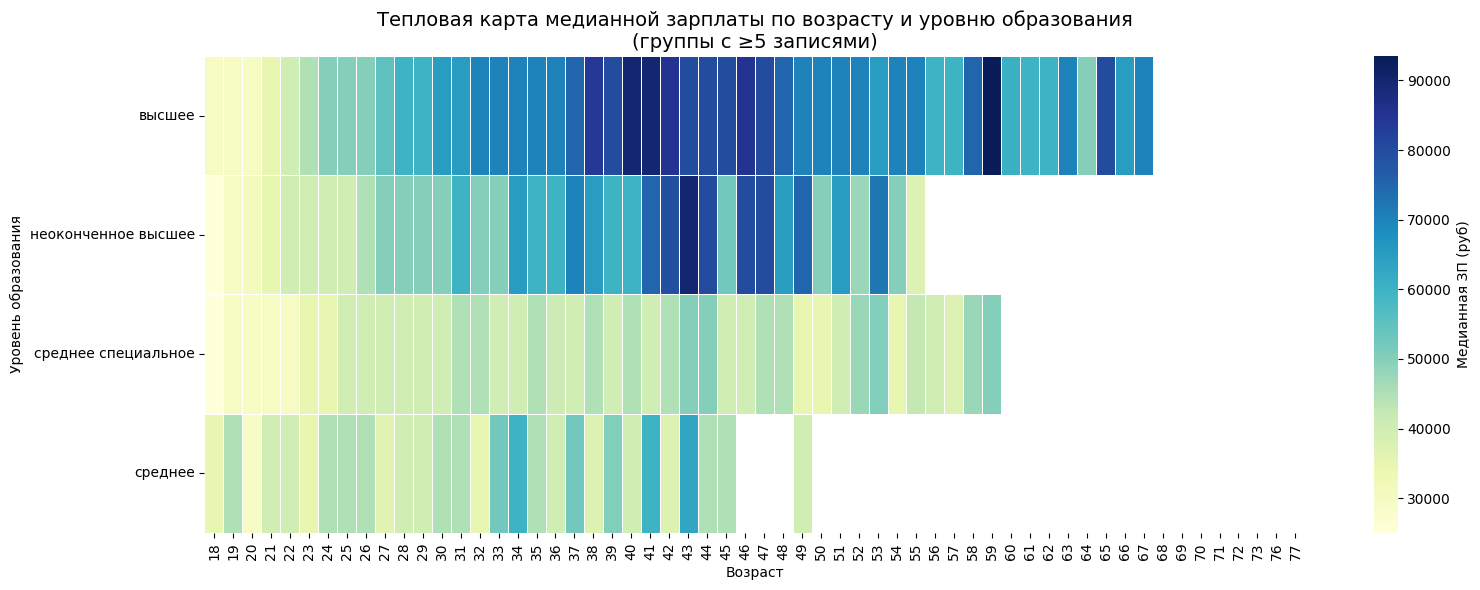

In [193]:
print("АНАЛИЗ КАРЬЕРНОГО РОСТА")

# Подготовка данных
df_analysis = df.dropna(subset=['ЗП (руб)', 'Возраст', 'Образование'])
df_analysis = df_analysis[(df_analysis['Возраст'] >= 18) & (df_analysis['Возраст'] <= 80)]

# Сводная таблица — медианная ЗП по возрасту и образованию
pivot_median = df_analysis.pivot_table(
    values='ЗП (руб)',
    index='Образование',
    columns='Возраст',
    aggfunc='median'
)

# Считаем количество записей в каждой группе
pivot_count = df_analysis.pivot_table(
    values='ЗП (руб)',
    index='Образование',
    columns='Возраст',
    aggfunc='size'
)

# Фильтруем: только группы с ≥5 записями (надёжные данные)
MIN_COUNT = 5
mask = pivot_count >= MIN_COUNT
pivot_filtered = pivot_median.where(mask)

# ПОРЯДОК КАТЕГОРИЙ
education_order = [
    'высшее',
    'неоконченное высшее',
    'среднее специальное',
    'среднее'
]

# Применяем порядок к сводной таблице
pivot_filtered = pivot_filtered.reindex(education_order)

# Убираем строки, где нет данных (на всякий случай)
pivot_filtered = pivot_filtered.dropna(how='all')

# Анализ роста зарплаты: сравнение интервалов 20–25 и 35–40 лет
early_range = slice(20, 25)
late_range = slice(35, 40)

def get_salary_growth(edu):
    early_vals = pivot_filtered.loc[edu].loc[early_range].dropna()
    late_vals = pivot_filtered.loc[edu].loc[late_range].dropna()
    
    if early_vals.empty or late_vals.empty:
        return None, None, None
    
    avg_early = early_vals.mean()
    avg_late = late_vals.mean()
    annual_growth = (avg_late - avg_early) / 15  # разница в возрасте ~15 лет
    
    return avg_early, avg_late, annual_growth

# Расчёт прироста для всех категорий
print("\nРОСТ ЗАРПЛАТЫ ПО ОБРАЗОВАНИЮ")
growth_results = {}
for edu in pivot_filtered.index:
    res = get_salary_growth(edu)
    if res[0] is not None:
        growth_results[edu] = res[2]
        print(f"{edu}:")
        print(f"  20–25 лет:  {res[0]:,.0f} руб.")
        print(f"  35–40 лет:  {res[1]:,.0f} руб.")
        print(f"  Прирост:    {res[2]:,.0f} руб/год")

# Определяем категорию с максимальным ростом
if growth_results:
    fastest_edu = max(growth_results, key=growth_results.get)
    print(f"\n ОТВЕТ НА ЗАДАНИЕ:")
    print(f"Наиболее быстрый карьерный рост — у категории: '{fastest_edu}'")
else:
    print("\n Недостаточно данных для анализа.")

# Тепловая карта
plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_filtered,
    cmap='YlGnBu',
    cbar_kws={'label': 'Медианная ЗП (руб)'},
    annot=False,
    linewidths=0.5
)
plt.title('Тепловая карта медианной зарплаты по возрасту и уровню образования\n(группы с ≥5 записями)', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Уровень образования')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Выводы

На тепловой карте видно, что все группы демонстрируют рост зарплаты с возрастом, но с разной интенсивностью.

Анализ зависимости медианной заработной платы от возраста и уровня образования показал, что наибольшая интенсивность карьерного роста наблюдается у соискателей с *высшим образованием* — в среднем на *2 433 рубля в год* в период с 20 до 40 лет.

Это обусловлено следующими факторами:
- Выпускники вузов начинают карьеру уже в возрасте 18–25 лет, часто с позиций стажёров или junior-специалистов.
- К 35–40 годам они достигают уровней middle/senior, руководящих должностей, особенно в IT, финансах и управлении.
- Эти сферы характеризуются высоким потенциалом вертикального роста и значительным увеличением дохода.

В то же время:
- Обладатели *среднего специального образования* демонстрируют более скромный рост (+622 руб/год), несмотря на раннее начало карьеры.
- Уровни *неоконченного высшего* и *среднего* образования показывают ещё более умеренный прирост.

Таким образом, именно *высшее образование* обеспечивает наиболее динамичное развитие карьеры и самый быстрый рост заработной платы.

In [194]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 25

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)
25. Переезд_Командировки

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-n

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

In [195]:
print("АНОМАЛИИ В ДАННЫХ")

# Готовим данные

# Фильтруем данные
df_scatter = df.dropna(subset=['Возраст', 'Опыт работы (месяц)']).copy()

# Переводим опыт из месяцев в годы
df_scatter['Опыт работы (годы)'] = df_scatter['Опыт работы (месяц)'] / 12

# Убираем явные выбросы (возраст > 100 или опыт > 100 лет)
df_scatter = df_scatter[
    (df_scatter['Возраст'] <= 100) &
    (df_scatter['Опыт работы (годы)'] <= 100)
]

# Создаём график
fig = px.scatter(
    df_scatter,
    x='Возраст',
    y='Опыт работы (годы)',
    title="Зависимость опыта работы от возраста",
    labels={
        'Возраст': 'Возраст (лет)',
        'Опыт работы (годы)': 'Опыт работы (годы)'
    },
    opacity=0.6,
    height=600
)

# Добавляем прямую y = x (опыт = возраст)
fig.add_shape(
    type='line',
    x0=0, y0=0,
    x1=100, y1=100,
    line=dict(color='red', width=2, dash='dash'),
    name='y = x'
)

fig.update_layout(
    showlegend=True,
    xaxis_range=[0, 100],
    yaxis_range=[0, 100]
)

fig.show()

# Поиск аномалий

# # Фильтр: опыт в годах > возраст
anomalies = df_scatter[df_scatter['Опыт работы (годы)'] > df_scatter['Возраст']]

# Количество аномальных записей
anomaly_count = len(anomalies)

print(f"\nРЕЗУЛЬТАТЫ")
print(f"Общее количество записей: {len(df_scatter):,}")
print(f"Количество аномалий (опыт > возраст): {anomaly_count}")

# Покажем несколько примеров
if anomaly_count > 0:
    print(f"\nПримеры аномалий:")
    print(anomalies[['Возраст', 'Опыт работы (месяц)', 'Опыт работы (годы)']].head())
else:
    print("Аномалий не найдено.") 

АНОМАЛИИ В ДАННЫХ



РЕЗУЛЬТАТЫ
Общее количество записей: 44,574
Количество аномалий (опыт > возраст): 7

Примеры аномалий:
       Возраст  Опыт работы (месяц)  Опыт работы (годы)
4535        18                271.0           22.583333
19351       28                470.0           39.166667
19872       34                416.0           34.666667
26477       34                411.0           34.250000
29098       14                477.0           39.750000


# Аномалии: опыт работы больше возраста

На диаграмме рассеяния показана зависимость опыта работы от возраста соискателей. Красная пунктирная линия — это прямая `y = x`, где опыт равен возрасту. Ни один человек не может иметь опыт больше возраста, поэтому все точки *выше этой прямой* — аномалии.

Анализ показал, что *7 соискателей* указали опыт работы, превышающий их возраст. Это физически невозможно и говорит о:
- Ошибках при заполнении резюме
- Ошибке в парсинге данных
- Неправильной интерпретации "опыта"

Такие записи следует удалить или пометить как недостоверные при дальнейшей очистке данных.

In [196]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 25

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)
25. Переезд_Командировки

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-n

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


In [197]:
# ЗАРПЛАТА ПО ВОЗРАСТУ
print('ЗАРПЛАТА ПО ВОЗРАСТУ')

avg_salary_by_age = df.groupby('Возраст')['ЗП (руб)'].median()
fig = px.line(avg_salary_by_age.reset_index(), x='Возраст', y='ЗП (руб)')
fig.show()

ЗАРПЛАТА ПО ВОЗРАСТУ


### Вывод:
После 40 лет наблюдается не стабилизация, а волатильность зарплаты: есть пики (например, в 69 и 77 годах), а также значительные спады (в 76). Это может указывать на выход на рынок специалистов с уникальным опытом или на аномалии в данных (например, соискатели с очень высокими ожиданиями в старшем возрасте).

In [198]:
# КОРРЕЛЯЦИЯ МЕЖДУ ВОЗРАСТОМ И ОПЫТОМ
print('КОРРЕЛЯЦИЯ МЕЖДУ ВОЗРАСТОМ И ОПЫТОМ')

fig = px.scatter(df, x='Возраст', y='Опыт работы (годы)', trendline='ols')
fig.show()

КОРРЕЛЯЦИЯ МЕЖДУ ВОЗРАСТОМ И ОПЫТОМ


### Вывод:
График показывает сильную линейную зависимость между возрастом и опытом работы. Линия тренда (OLS) почти совпадает с формулой: *опыт = возраст - 18*, что указывает на то, что большинство людей начинают карьеру в 18 лет.

Это важное наблюдение — оно позволяет использовать возраст как индикатор опыта, особенно если опыт не указан в резюме.

In [199]:
# ВЫБИРАЕМЫЕ ФОРМАТ И ГРАФИК РАБОТЫ СОИСКАТЕЛЯМИ
# Списки бинарных столбцов
employment_cols = [col for col in df.columns if col.startswith('Занятость_')]
schedule_cols = [col for col in df.columns if col.startswith('График_')]

# Извлекаем название занятости (первое True) или "несколько"
def get_employment_choice(row):
    selected = row[employment_cols]
    true_categories = selected[selected].index.tolist()
    if len(true_categories) == 0:
        return 'не указано'
    elif len(true_categories) == 1:
        return true_categories[0].replace('Занятость_', '')
    else:
        return 'несколько'

# Аналогично для графика
def get_schedule_choice(row):
    selected = row[schedule_cols]
    true_categories = selected[selected].index.tolist()
    if len(true_categories) == 0:
        return 'не указано'
    elif len(true_categories) == 1:
        return true_categories[0].replace('График_', '')
    else:
        return 'несколько'

# Применяем функции
df['Выбранная_занятость'] = df.apply(get_employment_choice, axis=1)
df['Выбранный_график'] = df.apply(get_schedule_choice, axis=1)

# Считаем общее количество форматов (для текста на графике)
df['Количество_форматов'] = (
    df[employment_cols].sum(axis=1) + 
    df[schedule_cols].sum(axis=1)
)

# Группируем по комбинациям и считаем, сколько таких соискателей
combo_stats = df.groupby(['Выбранная_занятость', 'Выбранный_график']).agg(
    Количество_соискателей=('Количество_форматов', 'size'),  # сколько человек
    Среднее_количество_форматов=('Количество_форматов', 'mean')
).reset_index().round(1)

# Сортируем по популярности
combo_stats = combo_stats.sort_values('Количество_соискателей', ascending=False)


fig = px.bar(
    combo_stats.head(20),  # топ-20 самых частых комбинаций
    x='Выбранная_занятость',
    y='Количество_соискателей',
    color='Выбранный_график',
    title="Топ-20 комбинаций 'занятость + график' у соискателей",
    labels={
        'Выбранная_занятость': 'Формат занятости',
        'Количество_соискателей': 'Число соискателей',
        'Выбранный_график': 'График работы'
    },
    text='Количество_соискателей'
)

fig.update_traces(
    texttemplate='%{text:,}',  # формат чисел: 1,000
    textposition='outside'
)

fig.update_layout(
    height=600,
    xaxis_tickangle=-45,
    xaxis_title="Формат занятости",
    yaxis_title="Количество соискателей",
    legend_title="График работы",
    showlegend=True,
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()

## Самые популярные комбинации занятости и графика

На графике представлены топ-20 комбинаций форматов работы, которые указывают соискатели. 

Самая популярная пара — *"полная занятость + удалённая работа"*, за ней следуют *"полная занятость + полный день"* и *"частичная занятость + гибкий график"*.

Интересно, что люди, выбирающие несколько форматов занятости, чаще всего комбинируют их с *гибким графиком* или *удалённой работой*, что говорит о стремлении к максимальной адаптивности.

Такой анализ помогает рекрутерам понимать, какие условия труда наиболее востребованы на рынке.

In [200]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 28

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)
24. Опыт работы (годы)
25. Переезд_Командировки
26. Выбранная_занятость
27. Выбранный_график
28. Количество_форматов

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           ----

In [201]:
# Удаляем ВСЕ вспомогательные столбцы, созданные для графиков в блоке 4.x
cols_to_drop = [
    'Опыт работы (годы)',       # ← копия, мешает только визуально
    'Переезд_Командировки',     # ← строковое объединение — источник шума
    'Выбранная_занятость',      # ← порядок слов может различаться
    'Выбранный_график',         # ← то же
    'Количество_форматов'       # ← int, но не нужен для очистки
]

# Удаляем их, если они есть
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
print(f"Удалено {len(cols_to_drop)} вспомогательных столбцов.")
print(f"Текущая размерность: {df_clean.shape}")

Удалено 5 вспомогательных столбцов.
Текущая размерность: (44744, 23)


In [202]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_clean)}")
print(f"Количество столбцов: {len(df_clean.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_clean.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_clean.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44744
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работ

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [203]:
# Проверяем количество полных дубликатов
duplicated_rows = df.duplicated()
num_duplicates = duplicated_rows.sum()

print(f"Количество полных дубликатов: {num_duplicates}")

# Удаляем дубликаты (оставляем первую копию)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Размерность после удаления дубликатов: {df_clean.shape}")

Количество полных дубликатов: 158
Размерность после удаления дубликатов: (44586, 23)


In [204]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_clean)}")
print(f"Количество столбцов: {len(df_clean.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_clean.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_clean.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44586
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44586 entries, 0 to 44585
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44586 non-null  object 
 1   Последнее/нынешнее место работ

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [205]:
# Выводим количество пропусков по всем столбцам
print("Количество пропусков в каждом столбце:")
missing = df_clean.isnull().sum()
print(missing[missing > 0])

# Конкретно по нужному столбцу
exp_missing = df_clean['Опыт работы (месяц)'].isnull().sum()
print(f"\nПропусков в 'Опыт работы (месяц)': {exp_missing}")

Количество пропусков в каждом столбце:
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Опыт работы (месяц)                168
dtype: int64

Пропусков в 'Опыт работы (месяц)': 168


In [206]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_clean)}")
print(f"Количество столбцов: {len(df_clean.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_clean.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_clean.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44586
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44586 entries, 0 to 44585
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44586 non-null  object 
 1   Последнее/нынешнее место работ

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [207]:
# ОЧИСТКА ПРОПУСКОВ

# 1. Удаляем строки с пропусками в 'месте работы' и 'должности'
#    (строки, где хотя бы в одном из этих двух столбцов NaN)
cols_critical = ['Последнее/нынешнее место работы', 'Последняя/нынешняя должность']
df_after_drop = df_clean.dropna(subset=cols_critical, how='any').reset_index(drop=True)

print(f"После удаления строк с пропусками в месте/должности: {df_after_drop.shape}")

# 2. Проверим, сколько пропусков осталось в 'Опыт работы (месяц)'
exp_missing_after_drop = df_after_drop['Опыт работы (месяц)'].isnull().sum()
print(f"Пропусков в 'Опыт работы (месяц)' после удаления критичных строк: {exp_missing_after_drop}")

# 3. Вычисляем МЕДИАНУ по существующим значениям
median_exp = df_after_drop['Опыт работы (месяц)'].median()
print(f"Медианное значение опыта (месяцы): {median_exp:.2f}")

# 4. Заполняем оставшиеся пропуски МЕДИАНОЙ
df_filled = df_after_drop.copy()
df_filled['Опыт работы (месяц)'] = df_filled['Опыт работы (месяц)'].fillna(median_exp)

# 5. Убедимся, что пропусков больше нет
final_missing = df_filled['Опыт работы (месяц)'].isnull().sum()
print(f"Пропусков после заполнения: {final_missing}")  # → 0 ✅

# 6. Считаем СРЕДНЕЕ значение (в месяцах) и округляем до целого
mean_exp_after = df_filled['Опыт работы (месяц)'].mean()
mean_exp_rounded = round(mean_exp_after)
print(f"Средний опыт (месяцы) после очистки и заполнения: {mean_exp_after:.2f} → округлённо: {mean_exp_rounded}")

После удаления строк с пропусками в месте/должности: (44584, 23)


Пропусков в 'Опыт работы (месяц)' после удаления критичных строк: 168
Медианное значение опыта (месяцы): 100.00
Пропусков после заполнения: 0
Средний опыт (месяцы) после очистки и заполнения: 114.36 → округлённо: 114


In [208]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_filled)}")
print(f"Количество столбцов: {len(df_filled.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_filled.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_filled.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44584
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44584 entries, 0 to 44583
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44584 non-null  object 
 1   Последнее/нынешнее место работ

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [209]:
# УДАЛЕНИЕ ВЫБРОСОВ ПО ЗАРПЛАТЕ
# Условие: ЗП < 1 000 руб или > 1 000 000 руб

# 1. Формируем маску выбросов
outliers_mask = (df_filled['ЗП (руб)'] < 1_000) | (df_filled['ЗП (руб)'] > 1_000_000)

# 2. Считаем количество выбросов
num_outliers = outliers_mask.sum()
print(f"Количество выбросов по ЗП (руб): {num_outliers}")

# 3. Показываем первые 5 выбросов для проверки
if num_outliers > 0:
    print("\nПримеры выбросов (первые 5):")
    print(df_filled[outliers_mask][['ЗП (руб)']].head())

# 4. Удаляем выбросы — перезаписываем df_filled
df_filled = df_filled[~outliers_mask].reset_index(drop=True)

# 5. Проверяем новую размерность
print(f"\nРазмерность после удаления выбросов: {df_filled.shape}")

Количество выбросов по ЗП (руб): 89

Примеры выбросов (первые 5):
      ЗП (руб)
253   420.0000
513   160.0000
550   452.7558
1083    1.0000
2231  250.0000

Размерность после удаления выбросов: (44495, 23)


In [210]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_filled)}")
print(f"Количество столбцов: {len(df_filled.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_filled.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_filled.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44495
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44495 entries, 0 to 44494
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44495 non-null  object 
 1   Последнее/нынешнее место работ

5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [211]:
# УДАЛЕНИЕ ВЫБРОСОВ (ОПЫТ > ВОЗРАСТ)

# 1. Проверим, что у нас есть нужные столбцы
assert 'Опыт работы (месяц)' in df_filled.columns, "Нет столбца 'Опыт работы (месяц)'"
assert 'Возраст' in df_filled.columns, "Нет столбца 'Возраст'"

# 2. Переводим опыт из месяцев в годы без округления
df_filled['Опыт работы (годы)'] = df_filled['Опыт работы (месяц)'] / 12

# 3. Формируем маску: где опыт в годах строго больше возраста
mask_experience_outliers = df_filled['Опыт работы (годы)'] > df_filled['Возраст']

# 4. Считаем количество таких строк
num_experience_outliers = mask_experience_outliers.sum()
print(f"Количество выбросов (опыт > возраст): {num_experience_outliers}")

# 5. Посмотрим примеры таких резюме для проверки
if num_experience_outliers > 0:
    print("\nПримеры невалидных резюме (опыт > возраст):")
    sample = df_filled[mask_experience_outliers][
        ['Возраст', 'Опыт работы (месяц)', 'Опыт работы (годы)', 'Ищет работу на должность:']
    ].head(3)
    print(sample)

# 6. Удаляем эти строки — обновляем df_filled
df_filled = df_filled[~mask_experience_outliers].reset_index(drop=True)

# 7. Проверим новую размерность
print(f"\nРазмерность после удаления выбросов: {df_filled.shape}")

# 8. Удаляем добавленный ранее признак для анализа
df_filled = df_filled.drop(columns=['Опыт работы (годы)'], errors='ignore')
print('Признак - "Опыт работы (годы)"')

# 9. Проверим новую размерность
print(f"\nРазмерность после удаления вспомогательного признака: {df_filled.shape}")

Количество выбросов (опыт > возраст): 7

Примеры невалидных резюме (опыт > возраст):
       Возраст  Опыт работы (месяц)  Опыт работы (годы)  \
4464        18                271.0           22.583333   
19155       28                470.0           39.166667   
19676       34                416.0           34.666667   

             Ищет работу на должность:  
4464            Технический специалист  
19155  Специалист (Junior-программист)  
19676                         Аналитик  

Размерность после удаления выбросов: (44488, 24)
Признак - "Опыт работы (годы)"

Размерность после удаления вспомогательного признака: (44488, 23)


In [212]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_filled)}")
print(f"Количество столбцов: {len(df_filled.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_filled.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_filled.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44488
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44488 entries, 0 to 44487
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44488 non-null  object 
 1   Последнее/нынешнее место работ

6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

μ = 3.4440, σ = 0.2310
Количество выбросов: 3


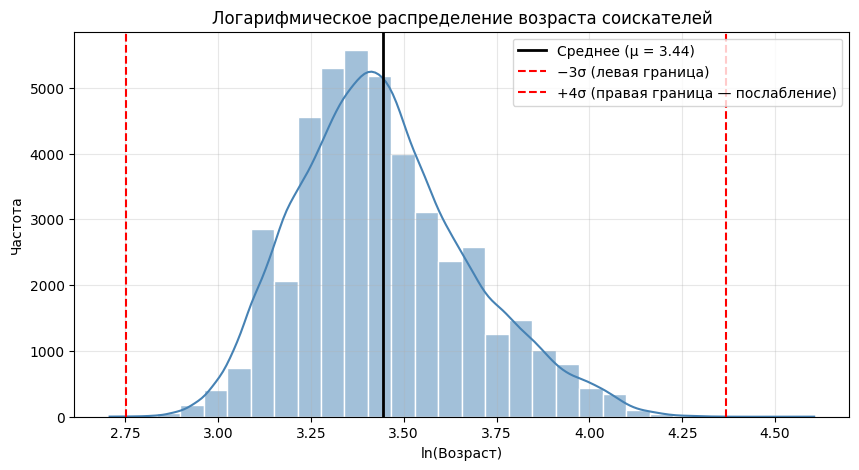


Возраст соискателей-выбросов:
[100, 15, 15]
✅ Размерность после удаления выбросов: (44485, 23)


In [213]:
# ЛОГ-РАСПРЕДЕЛЕНИЕ ВОЗРАСТА + ВЫБРОСЫ (z < -3 или z > +4)

# 1. Извлекаем возраст как массив (гарантируем совпадение длины)
age_vals = df_filled['Возраст'].values.astype(float)  # (N,)
log_age = np.log(age_vals)                          # (N,)

# 2. Считаем параметры норм. распределения (генеральная совокупность)
mu = np.mean(log_age)
sigma = np.std(log_age, ddof=0)
print(f"μ = {mu:.4f}, σ = {sigma:.4f}")

# 3. Z-оценки
z_scores = (log_age - mu) / sigma

# 4. Асимметричная маска выбросов: z < −3 ИЛИ z > +4 (послабление вправо)
mask_outliers = (z_scores < -3) | (z_scores > 4)
num_outliers = int(mask_outliers.sum())
print(f"Количество выбросов: {num_outliers}")

# 5. Построение гистограммы в логарифмическом масштабе
plt.figure(figsize=(10, 5))
histplot = sns.histplot(log_age, bins=30, kde=True, color='steelblue', edgecolor='white')

# Добавляем линии: μ, μ−3σ, μ+4σ
histplot.axvline(mu, color='k', lw=2, label=f'Среднее (μ = {mu:.2f})')
histplot.axvline(mu - 3 * sigma, color='r', ls='--', lw=1.5, label='−3σ (левая граница)')
histplot.axvline(mu + 4 * sigma, color='r', ls='--', lw=1.5, label='+4σ (правая граница — послабление)')

# Оформление графика
plt.title('Логарифмическое распределение возраста соискателей')
plt.xlabel('ln(Возраст)')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Вывод таблицы выбросов (если есть)
if num_outliers > 0:
    outliers_ages = df_filled[mask_outliers]['Возраст'].sort_values(ascending=False)
    print("\nВозраст соискателей-выбросов:")
    print(outliers_ages.values.tolist())

# 7. Удаляем только выбросы — логическое индексирование
df_filled = df_filled[~mask_outliers].reset_index(drop=True)
print(f"✅ Размерность после удаления выбросов: {df_filled.shape}")

In [214]:
# Основная информация о данных
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
print(f"Общее количество записей: {len(df_filled)}")
print(f"Количество столбцов: {len(df_filled.columns)}")
print("\nНазвания столбцов:")
for i, col in enumerate(df_filled.columns):
    print(f"{i+1}. {col}")

# Информация о типах данных и пропусках
print("\n=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(df_filled.info())

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество записей: 44485
Количество столбцов: 23

Названия столбцов:
1. Ищет работу на должность:
2. Последнее/нынешнее место работы
3. Последняя/нынешняя должность
4. Обновление резюме
5. Авто
6. Образование
7. Пол
8. Возраст
9. Опыт работы (месяц)
10. Город
11. Готовность к переезду
12. Готовность к командировкам
13. Занятость_полная занятость
14. Занятость_частичная занятость
15. Занятость_проектная работа
16. Занятость_волонтерство
17. Занятость_стажировка
18. График_полный день
19. График_сменный график
20. График_гибкий график
21. График_удалённая работа
22. График_вахтовый метод
23. ЗП (руб)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44485 entries, 0 to 44484
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44485 non-null  object 
 1   Последнее/нынешнее место работ

# Пояснение к графику
Распределение демонстрирует правостороннюю асимметрию: правый хвост (соискатели старше 65 лет) более выражен, чем левый.\
Это связано с наличием редких, но реальных кандидатов в возрасте 70+ лет при основном кластере 20–45 лет.\
Такая асимметрия объясняет, почему мы используем логарифмический масштаб — чтобы сделать распределение ближе к нормальному и применить метод z-отклонений.\
Также она показывает, что пожилые соискатели — не артефакт данных, а реальный феномен, который нужно учитывать при анализе рынка труда.